In [1]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
from timm import create_model
from PIL import Image
from tqdm import tqdm
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import defaultdict

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from metrics.CKA import linear_CKA
from metrics.CKNNA import AlignmentMetrics

Please install the pymp library using `pip install pymp` to speed up non-batched metrics


### Experiment: Layer Skipping and Representation Similarity in DINO ViTs

This experiment is part of a broader analysis aimed at evaluating the representational quality of different layers in a pretrained Vision Transformer (ViT), specifically the self-supervised DINO model. We extract features from each transformer block and train lightweight linear classifiers (linear probes) to measure how linearly separable the learned representations are at each depth of the network.

The primary objective is to identify which layers encode the most semantically useful information for classification tasks. This foundational analysis enables further investigations into model efficiency—particularly strategies such as layer skipping or representational redundancy detection—aiming to reduce inference cost without significantly degrading performance.

#### Models Used

- **DINO ViT-S/16**
- **DINO ViT-B/8**

#### Layer Skipping Setup

We simulate the skipping of one or two consecutive transformer blocks. For each layer `l`, we:

- Forward the output of layer `l` directly to `l+2` or `l+3`, bypassing one or two intermediate layers.
- Extract the modified embedding and evaluate it using a fixed, pretrained linear classifier trained on original DINO embeddings.

This allows us to isolate and assess the impact of each block’s contribution to the final feature quality.

#### Metrics Evaluated

We measure the effect of skipping on classification performance using:

- **Global metrics** (mean ± standard deviation across runs):
  - Accuracy
  - Macro-averaged precision, recall, and F1-score
- **Per-class metrics**:
  - Accuracy, precision, recall, and F1-score (mean and std per class)

These metrics provide both high-level insight into model robustness and fine-grained information about class-specific sensitivity to representational degradation.

#### Evaluation Settings

Each configuration is tested under three conditions:

1. **No skipping** (baseline)
2. **Skip one layer**: output from `l` is forwarded to `l+2`
3. **Skip two layers**: output from `l` is forwarded to `l+3`

This is repeated for multiple values of `l`, and across both model variants (ViT-S/16 and ViT-B/8), to generalize findings.

#### Broader Goals

By combining linear probing with structural interventions (layer skipping), we aim to:

- Identify critical vs. redundant layers in the DINO ViT architecture
- Correlate drop in accuracy with representational similarity between layers
- Lay groundwork for efficient inference strategies, such as selective execution, early exits, or transformer block pruning


In [2]:
def extract_layer_outputs(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    return activations


def compute_logits_from_layers(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]  # CLS token
    norm = model.norm
    head = model.head
    logits = [head(norm(cls)) for cls in cls_tokens]
    return logits


def collect_logits_from_batches(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_batch = x_batch.to(next(model.parameters()).device)
        layer_outputs = extract_layer_outputs(model, x_batch)
        logits = compute_logits_from_layers(model, layer_outputs)
        all_logits.append(logits)

    return all_logits

In [3]:
def compute_cka_matrix(logits):
    L = len(logits)
    matrix = torch.zeros(L, L)
    logits = [F.normalize(logit.detach(), dim=-1) for logit in logits]

    for i in range(L):
        for j in range(i, L):
            val = linear_CKA(logits[i], logits[j])
            matrix[i, j] = val
            matrix[j, i] = val

    return matrix.numpy()


def compute_cosine_similarity_matrix(logits):
    """
    Fully vectorized computation of cosine similarity matrix between L layer outputs.
    Uses F.cosine_similarity and removes nested loops.
    """
    x = torch.stack([F.normalize(t.detach(), dim=-1) for t in logits])

    x1 = x[:, None, :, :] 
    x2 = x[None, :, :, :]

    cos = F.cosine_similarity(x1, x2, dim=-1)

    sim_matrix = cos.mean(dim=-1)

    return sim_matrix.cpu().numpy()


def compute_cknna_matrix(logits, k=10):
    L = len(logits)
    matrix = np.zeros((L, L))
    
    for i in range(L):
        for j in range(i, L):
            sim = AlignmentMetrics.cknna(logits[i], logits[j], topk=k)
            matrix[i, j] = sim
            matrix[j, i] = sim
    
    return matrix

In [4]:
def evaluate_full_model(model, val_dataset, linear_classifier, max_layer=12, max_batches=None, num_repeats=3):
    results = []

    print("\n[INFO] Evaluating full model...\n")

    accs = []
    precs_macro = []
    recs_macro = []
    f1s_macro = []

    precs_per_class_list = []
    recs_per_class_list = []
    f1s_per_class_list = []
    accs_per_class_list = []


    for repeat in range(num_repeats):
        torch.manual_seed(42+100*repeat**4)
        random.seed(42+100*repeat**4)
        np.random.seed(42+100*repeat**4)
        dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
        print(f"[INFO] Full model, repeat {repeat + 1}/{num_repeats}")
        X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=[], max_batches=max_batches)

        inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs = linear_classifier(inputs)
            y_pred = outputs.argmax(dim=1).cpu().numpy()

        acc = accuracy_score(y_val, y_pred)
        prec_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)

        prec_per_class = precision_score(y_val, y_pred, average=None, zero_division=0)
        rec_per_class = recall_score(y_val, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_val, y_pred, average=None, zero_division=0)

        unique_classes = np.unique(y_val)
        acc_per_class = {}
        for cls in unique_classes:
            idx = y_val == cls
            acc_cls = (y_pred[idx] == y_val[idx]).mean()
            acc_per_class[int(cls)] = acc_cls
        print(acc_per_class)

        accs.append(acc)
        precs_macro.append(prec_macro)
        recs_macro.append(rec_macro)
        f1s_macro.append(f1_macro)

        precs_per_class_list.append(dict(zip(unique_classes, prec_per_class)))
        recs_per_class_list.append(dict(zip(unique_classes, rec_per_class)))
        f1s_per_class_list.append(dict(zip(unique_classes, f1_per_class)))
        accs_per_class_list.append(acc_per_class)

    def mean_std_dicts(dict_list):
        keys = dict_list[0].keys()
        mean_dict = {}
        std_dict = {}
        for k in keys:
            vals = [d[k] for d in dict_list]
            mean_dict[k] = np.mean(vals)
            std_dict[k] = np.std(vals)
        return mean_dict, std_dict

    precs_per_class_mean, precs_per_class_std = mean_std_dicts(precs_per_class_list)
    recs_per_class_mean, recs_per_class_std = mean_std_dicts(recs_per_class_list)
    f1s_per_class_mean, f1s_per_class_std = mean_std_dicts(f1s_per_class_list)
    accs_per_class_mean, accs_per_class_std = mean_std_dicts(accs_per_class_list)

    results.append({
        'skipped_layers': [],
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'precision_mean': np.mean(precs_macro),
        'precision_std': np.std(precs_macro),
        'recall_mean': np.mean(recs_macro),
        'recall_std': np.std(recs_macro),
        'f1_mean': np.mean(f1s_macro),
        'f1_std': np.std(f1s_macro),

        'accuracy_per_class_mean': accs_per_class_mean,
        'accuracy_per_class_std': accs_per_class_std,
        'precision_per_class_mean': precs_per_class_mean,
        'precision_per_class_std': precs_per_class_std,
        'recall_per_class_mean': recs_per_class_mean,
        'recall_per_class_std': recs_per_class_std,
        'f1_per_class_mean': f1s_per_class_mean,
        'f1_per_class_std': f1s_per_class_std,
    })

    return results


In [5]:
def evaluate_skipped_layers(model, val_dataset, linear_classifier, max_layer=12, max_batches=None, num_repeats=3):
    results = []

    print("\n[INFO] Evaluating individual skipped layers...\n")
    for i in range(max_layer):
        skipped = [i]
        accs = []
        precs_macro = []
        recs_macro = []
        f1s_macro = []

        precs_per_class_list = []
        recs_per_class_list = []
        f1s_per_class_list = []
        accs_per_class_list = []

        for repeat in range(num_repeats):

            torch.manual_seed(42+100*repeat**4)
            random.seed(42+100*repeat**4)
            np.random.seed(42+100*repeat**4)
            dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
            print(f"[INFO] Skipping layer {skipped}, repeat {repeat + 1}/{num_repeats}")
            X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)

            inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
            with torch.no_grad():
                outputs = linear_classifier(inputs)
                y_pred = outputs.argmax(dim=1).cpu().numpy()

            acc = accuracy_score(y_val, y_pred)
            prec_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
            rec_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)

            prec_per_class = precision_score(y_val, y_pred, average=None, zero_division=0)
            rec_per_class = recall_score(y_val, y_pred, average=None, zero_division=0)
            f1_per_class = f1_score(y_val, y_pred, average=None, zero_division=0)

            unique_classes = np.unique(y_val)
            acc_per_class = {}
            for cls in unique_classes:
                idx = y_val == cls
                acc_cls = (y_pred[idx] == y_val[idx]).mean()
                acc_per_class[int(cls)] = acc_cls

            accs.append(acc)
            precs_macro.append(prec_macro)
            recs_macro.append(rec_macro)
            f1s_macro.append(f1_macro)

            precs_per_class_list.append(dict(zip(unique_classes, prec_per_class)))
            recs_per_class_list.append(dict(zip(unique_classes, rec_per_class)))
            f1s_per_class_list.append(dict(zip(unique_classes, f1_per_class)))
            accs_per_class_list.append(acc_per_class)

        def mean_std_dicts(dict_list):
            keys = dict_list[0].keys()
            mean_dict = {}
            std_dict = {}
            for k in keys:
                vals = [d[k] for d in dict_list]
                mean_dict[k] = np.mean(vals)
                std_dict[k] = np.std(vals)
            return mean_dict, std_dict

        precs_per_class_mean, precs_per_class_std = mean_std_dicts(precs_per_class_list)
        recs_per_class_mean, recs_per_class_std = mean_std_dicts(recs_per_class_list)
        f1s_per_class_mean, f1s_per_class_std = mean_std_dicts(f1s_per_class_list)
        accs_per_class_mean, accs_per_class_std = mean_std_dicts(accs_per_class_list)

        results.append({
            'skipped_layers': skipped,
            'accuracy_mean': np.mean(accs),
            'accuracy_std': np.std(accs),
            'precision_mean': np.mean(precs_macro),
            'precision_std': np.std(precs_macro),
            'recall_mean': np.mean(recs_macro),
            'recall_std': np.std(recs_macro),
            'f1_mean': np.mean(f1s_macro),
            'f1_std': np.std(f1s_macro),

            'accuracy_per_class_mean': accs_per_class_mean,
            'accuracy_per_class_std': accs_per_class_std,
            'precision_per_class_mean': precs_per_class_mean,
            'precision_per_class_std': precs_per_class_std,
            'recall_per_class_mean': recs_per_class_mean,
            'recall_per_class_std': recs_per_class_std,
            'f1_per_class_mean': f1s_per_class_mean,
            'f1_per_class_std': f1s_per_class_std,
        })

    return results


In [6]:
def evaluate_skipped_layer_pairs(model, dataloader, linear_classifier, max_layer=12, max_batches=None, num_repeats=3):
    results = []

    print("\n[INFO] Evaluating pairs of skipped layers...\n")
    for i in range(max_layer - 1):
        skipped = [i, i + 1]
        accs = []
        precs_macro = []
        recs_macro = []
        f1s_macro = []

        precs_per_class_list = []
        recs_per_class_list = []
        f1s_per_class_list = []
        accs_per_class_list = []

        for repeat in range(num_repeats):

            torch.manual_seed(42+100*repeat**4)
            random.seed(42+100*repeat**4)
            np.random.seed(42+100*repeat**4)
            dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

            print(f"[INFO] Skipping layers {skipped}, repeat {repeat + 1}/{num_repeats}")
            X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)

            inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
            with torch.no_grad():
                outputs = linear_classifier(inputs)
                y_pred = outputs.argmax(dim=1).cpu().numpy()

            acc = accuracy_score(y_val, y_pred)
            prec_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
            rec_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)

            prec_per_class = precision_score(y_val, y_pred, average=None, zero_division=0)
            rec_per_class = recall_score(y_val, y_pred, average=None, zero_division=0)
            f1_per_class = f1_score(y_val, y_pred, average=None, zero_division=0)

            unique_classes = np.unique(y_val)
            acc_per_class = {}
            for cls in unique_classes:
                idx = y_val == cls
                acc_cls = (y_pred[idx] == y_val[idx]).mean()
                acc_per_class[int(cls)] = acc_cls

            accs.append(acc)
            precs_macro.append(prec_macro)
            recs_macro.append(rec_macro)
            f1s_macro.append(f1_macro)

            precs_per_class_list.append(dict(zip(unique_classes, prec_per_class)))
            recs_per_class_list.append(dict(zip(unique_classes, rec_per_class)))
            f1s_per_class_list.append(dict(zip(unique_classes, f1_per_class)))
            accs_per_class_list.append(acc_per_class)

        def mean_std_dicts(dict_list):
            keys = dict_list[0].keys()
            mean_dict = {}
            std_dict = {}
            for k in keys:
                vals = [d[k] for d in dict_list]
                mean_dict[k] = np.mean(vals)
                std_dict[k] = np.std(vals)
            return mean_dict, std_dict

        precs_per_class_mean, precs_per_class_std = mean_std_dicts(precs_per_class_list)
        recs_per_class_mean, recs_per_class_std = mean_std_dicts(recs_per_class_list)
        f1s_per_class_mean, f1s_per_class_std = mean_std_dicts(f1s_per_class_list)
        accs_per_class_mean, accs_per_class_std = mean_std_dicts(accs_per_class_list)

        results.append({
            'skipped_layers': skipped,
            'accuracy_mean': np.mean(accs),
            'accuracy_std': np.std(accs),
            'precision_mean': np.mean(precs_macro),
            'precision_std': np.std(precs_macro),
            'recall_mean': np.mean(recs_macro),
            'recall_std': np.std(recs_macro),
            'f1_mean': np.mean(f1s_macro),
            'f1_std': np.std(f1s_macro),

            'accuracy_per_class_mean': accs_per_class_mean,
            'accuracy_per_class_std': accs_per_class_std,
            'precision_per_class_mean': precs_per_class_mean,
            'precision_per_class_std': precs_per_class_std,
            'recall_per_class_mean': recs_per_class_mean,
            'recall_per_class_std': recs_per_class_std,
            'f1_per_class_mean': f1s_per_class_mean,
            'f1_per_class_std': f1s_per_class_std,
        })

    return results

In [7]:
def plot_single_skip_layer_accuracy_three_matrices_summary(
    results,
    cka_matrix,
    cos_matrix,
    cknna_matrix,
    results_full,
    title_prefix="Accuracy",
    model="B/8"
):
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]
    x = [res['skipped_layers'][0] for res in single_skip_results]

    similarity_matrices = {
        'CKA': cka_matrix,
        'Cosine': cos_matrix,
        'CKNNA': cknna_matrix
    }

    fig, axs = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

    full_accuracy = results_full[0]['accuracy_mean']

    norm_info = {} 

    for col_idx, (sim_name, sim_matrix) in enumerate(similarity_matrices.items()):
        similarities = []
        for res in single_skip_results:
            i = res['skipped_layers'][0]
            if i + 1 < sim_matrix.shape[0]:
                similarities.append(sim_matrix[i, i + 1])
            else:
                similarities.append(sim_matrix[i - 1, i])
        
        if sim_name == 'Cosine':
            norm = plt.Normalize(vmin=-1, vmax=1)
        else:
            norm = plt.Normalize(vmin=0, vmax=1)
        
        colors = cm.Spectral_r(norm(similarities))
        norm_info[col_idx] = norm

        ax = axs[col_idx]

        bars = ax.bar(x, [res['accuracy_mean'] for res in single_skip_results],
                      yerr=[res['accuracy_std'] for res in single_skip_results],
                      color=colors,
                      capsize=5,
                      edgecolor='black')

        ax.axhline(y=full_accuracy, color='red', linestyle='--', linewidth=2,
                   label='Full model accuracy')

        ax.set_title(sim_name)
        ax.set_xlabel("Skipped layer")
        ax.set_ylim(0, 1.05)
        if col_idx == 0:
            ax.set_ylabel(f"{title_prefix} (mean ± std)")
        ax.set_xticks(x)
        ax.grid(axis='y')

        ax.legend()

    fig.suptitle(
        f"Per-Model Accuracy with Single Skipped Layer on DINO ViT {model} Features\n"
        "Color indicates layer representation similarity (CKA, Cosine, CKNNA)",
        fontsize=18
    )
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    for col_idx, ax in enumerate(axs):
        norm = norm_info[col_idx]

        sim_name = list(similarity_matrices.keys())[col_idx]

        bbox = ax.get_position()
        center_x = (bbox.x0 + bbox.x1) / 2
        width = 0.3

        cbar_ax = fig.add_axes([
            center_x - width / 2,
            0.04,     
            width,
            0.015    
        ])
        sm = cm.ScalarMappable(norm=norm, cmap='Spectral_r')
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(f'{list(similarity_matrices.keys())[col_idx]} Similarity', fontsize=12)

    plt.show()

In [8]:
def plot_double_skip_layer_accuracy_three_matrices_summary(
    results,
    cka_matrix,
    cos_matrix,
    cknna_matrix,
    results_full,
    title_prefix="Accuracy",
    model="B/8"
):
    double_skip_results = [
        res for res in results
        if len(res['skipped_layers']) == 2 and res['skipped_layers'][1] - res['skipped_layers'][0] == 1
    ]

    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))

    similarity_matrices = {
        'CKA': cka_matrix,
        'Cosine': cos_matrix,
        'CKNNA': cknna_matrix
    }

    fig, axs = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
    plt.subplots_adjust(wspace=0.3, bottom=0.3, top=0.88)

    full_accuracy = results_full[0]['accuracy_mean']
    norm_info = {}

    for col_idx, (sim_name, sim_matrix) in enumerate(similarity_matrices.items()):
        similarities = []
        for res in double_skip_results:
            i = res['skipped_layers'][0]
            if i + 1 < sim_matrix.shape[0]:
                similarities.append(sim_matrix[i, i + 1])
            else:
                similarities.append(sim_matrix[i - 1, i])

        if sim_name == 'Cosine':
            norm = plt.Normalize(vmin=-1, vmax=1)
        else:
            norm = plt.Normalize(vmin=0, vmax=1)

        colors = cm.Spectral_r(norm(similarities))
        norm_info[col_idx] = norm

        ax = axs[col_idx]
        bars = ax.bar(
            x_pos,
            [res['accuracy_mean'] for res in double_skip_results],
            yerr=[res['accuracy_std'] for res in double_skip_results],
            color=colors,
            capsize=5,
            edgecolor='black'
        )

        ax.axhline(y=full_accuracy, color='red', linestyle='--', linewidth=2, label='Full model accuracy')
        ax.set_title(sim_name)
        ax.set_xlabel("Skipped layer pair")
        ax.set_ylim(0, 1.05)
        if col_idx == 0:
            ax.set_ylabel(f"{title_prefix} (mean ± std)")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=45, ha='right')
        ax.grid(axis='y')
        ax.legend()

    fig.suptitle(
        f"Per-Model Accuracy with Two Consecutive Skipped Layers on DINO ViT {model} Features\n"
        "Color Indicates Layer Representation Similarity (CKA, Cosine, CKNNA)",
        fontsize=18
    )

    fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    for col_idx, ax in enumerate(axs):
        norm = norm_info[col_idx]
        sim_name = list(similarity_matrices.keys())[col_idx]

        bbox = ax.get_position()
        center_x = (bbox.x0 + bbox.x1) / 2
        width = 0.3

        cbar_ax = fig.add_axes([
            center_x - width / 2,
            0.04, 
            width,
            0.015
        ])
        sm = cm.ScalarMappable(norm=norm, cmap='Spectral_r')
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(f'{sim_name} Similarity', fontsize=12)

    plt.show()


In [9]:
def plot_double_skip_layer_accuracy_per_class_three_matrices(
    results,
    cka_matrix,
    cos_matrix,
    cknna_matrix,
    results_full,
    num_classes=8,
    model="B/8"
    ):
    double_skip_results = [
        res for res in results
        if len(res['skipped_layers']) == 2 and res['skipped_layers'][1] - res['skipped_layers'][0] == 1
    ]

    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))

    similarity_matrices_raw = {
        'CKA': cka_matrix,
        'Cosine': cos_matrix,
        'CKNNA': cknna_matrix
    }

    full_acc_per_class = results_full[0]['accuracy_per_class_mean']

    fig, axs = plt.subplots(num_classes, 3, figsize=(18, 8 * num_classes), sharex='col', sharey='row')

    similarity_info = {}

    for col_idx, (sim_name, sim_matrix) in enumerate(similarity_matrices_raw.items()):
        similarities = []
        for res in double_skip_results:
            i = res['skipped_layers'][0]
            if i + 1 < sim_matrix.shape[0]:
                similarities.append(sim_matrix[i, i + 1])
            else:
                similarities.append(sim_matrix[i - 1, i])

        if sim_name == 'Cosine':
            norm = mcolors.Normalize(vmin=-1, vmax=1)
        else:
            norm = mcolors.Normalize(vmin=0, vmax=1)

        colors = cm.Spectral_r(norm(similarities))

        similarity_info[col_idx] = {
            "norm": norm,
            "sim_name": sim_name,
            "colors": colors
        }

        for class_idx in range(num_classes):
            acc_means = [res['accuracy_per_class_mean'].get(class_idx, 0) for res in double_skip_results]
            acc_stds = [res['accuracy_per_class_std'].get(class_idx, 0) for res in double_skip_results]

            ax = axs[class_idx, col_idx]
            ax.bar(x_pos, acc_means, yerr=acc_stds, color=colors, capsize=3, edgecolor='black')

            full_acc = full_acc_per_class.get(class_idx, 0)
            ax.axhline(y=full_acc, color='r', linestyle='--', linewidth=1)
            ax.tick_params(axis='both', which='major', labelsize=12)

            if col_idx == 0:
                ax.set_ylabel(f'Class {class_idx}')
            if class_idx == 0:
                ax.set_title(sim_name)
            ax.set_ylim(0, 1.05)
            ax.grid(True, axis='y')

            if class_idx == num_classes - 1:
                ax.set_xticks(x_pos)
                ax.set_xticklabels(x_labels, rotation=45, ha='right')

    fig.suptitle(f"Per-Class Linear Classifier Accuracy on DINO ViT {model} Features\n " \
    "with Two Consecutive Skipped Layers\n Color Indicates Layer Representation " \
    "Similarity (CKA, Cosine, CKNNA)", fontsize=25)
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])

    for col_idx in range(3):
        sim_name = similarity_info[col_idx]["sim_name"]
        norm = similarity_info[col_idx]["norm"]

        col_lefts = [axs[row, col_idx].get_position().x0 for row in range(num_classes)]
        col_rights = [axs[row, col_idx].get_position().x1 for row in range(num_classes)]
        col_x0 = min(col_lefts)
        col_x1 = max(col_rights)

        center_x = (col_x0 + col_x1) / 2
        width = 0.3

        cbar_ax = fig.add_axes([
            center_x - width / 2,
            0.02,
            width,
            0.008
        ])

        sm = cm.ScalarMappable(norm=norm, cmap='Spectral_r')
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(f'{sim_name} Similarity', fontsize=12)

    plt.show()

In [10]:
def plot_single_skip_layer_accuracy_per_class_three_matrices(
    results,
    cka_matrix,
    cos_matrix,
    cknna_matrix,
    results_full,
    num_classes=8,
    model="B/8"
):
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]
    x = [res['skipped_layers'][0] for res in single_skip_results]

    similarity_matrices_raw = {
        'CKA': cka_matrix,
        'Cosine': cos_matrix,
        'CKNNA': cknna_matrix
    }

    full_acc_per_class = results_full[0]['accuracy_per_class_mean']

    fig, axs = plt.subplots(num_classes, 3, figsize=(18, 8 * num_classes), sharex='col', sharey='row')

    similarity_info = {}

    for col_idx, (sim_name, sim_matrix) in enumerate(similarity_matrices_raw.items()):
        similarities = []
        for res in single_skip_results:
            i = res['skipped_layers'][0]
            if i + 1 < sim_matrix.shape[0]:
                similarities.append(sim_matrix[i, i + 1])
            else:
                similarities.append(sim_matrix[i - 1, i])

        if sim_name == 'Cosine':
            norm = mcolors.Normalize(vmin=-1, vmax=1)
        else:
            norm = mcolors.Normalize(vmin=0, vmax=1)

        colors = cm.Spectral_r(norm(similarities))

        similarity_info[col_idx] = {
            "norm": norm,
            "sim_name": sim_name,
            "colors": colors
        }

        for class_idx in range(num_classes):
            acc_means = [res['accuracy_per_class_mean'].get(class_idx, 0) for res in single_skip_results]
            acc_stds = [res['accuracy_per_class_std'].get(class_idx, 0) for res in single_skip_results]

            ax = axs[class_idx, col_idx]
            ax.bar(x, acc_means, yerr=acc_stds, color=colors, capsize=3, edgecolor='black')

            full_acc = full_acc_per_class.get(class_idx, 0)
            ax.axhline(y=full_acc, color='r', linestyle='--', linewidth=1)
            ax.tick_params(axis='both', which='major', labelsize=12)

            if col_idx == 0:
                ax.set_ylabel(f'Class {class_idx}')
            if class_idx == 0:
                ax.set_title(sim_name)
            ax.set_ylim(0, 1.05)
            ax.grid(True, axis='y')

            if class_idx == num_classes - 1:
                ax.set_xticks(x)
                ax.set_xticklabels(x, rotation=45, ha='right')

    fig.suptitle(
        f"Per-Class Linear Classifier Accuracy on DINO ViT {model} Features\n"
        "with Single Skipped Layer\n"
        "Color Indicates Layer Representation Similarity (CKA, Cosine, CKNNA)",
        fontsize=25
    )
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])  

    for col_idx in range(3):
        sim_name = similarity_info[col_idx]["sim_name"]
        norm = similarity_info[col_idx]["norm"]

        col_lefts = [axs[row, col_idx].get_position().x0 for row in range(num_classes)]
        col_rights = [axs[row, col_idx].get_position().x1 for row in range(num_classes)]
        col_x0 = min(col_lefts)
        col_x1 = max(col_rights)

        center_x = (col_x0 + col_x1) / 2
        width = 0.3
        cbar_ax = fig.add_axes([
            center_x - width / 2,
            0.02,      
            width,
            0.008     
        ])

        sm = cm.ScalarMappable(norm=norm, cmap='Spectral_r')
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(f'{sim_name} Similarity', fontsize=12)

    plt.show()


In [11]:
def plot_metric_per_class_single(results, metric_name='Accuracy', selected_classes=[0, 1, 2, 3, 4,5,6,7]):
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]
    layers = [res['skipped_layers'][0] for res in single_skip_results]

    for cls in selected_classes:
        values = [res["accuracy_per_class_mean"].get(cls, np.nan) for res in single_skip_results]
        plt.plot(layers, values, label=f"Class {cls}")

    plt.xlabel("Skipped layer")
    plt.ylabel(f"{metric_name.replace('_', ' ').title()} for selected classes")
    plt.title(f"Impact of Skipping a Single Layer on Per-Class {metric_name.replace('_', ' ')}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_metric_per_class_double(results, metric_name='Accuracy', selected_classes=[0, 1, 2, 3, 4,5,6,7]):
    double_skip_results = [res for res in results if len(res['skipped_layers']) == 2]
    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))
    for cls in selected_classes:
        values = [res["accuracy_per_class_mean"].get(cls, np.nan) for res in double_skip_results]
        plt.plot(x_pos, values, label=f"Class {cls}")

    plt.xlabel("Skipped layer")
    plt.ylabel(f"{metric_name.replace('_', ' ').title()} for selected classes")
    plt.title(f"Impact of Skipping Consecutive Layer Pairs on Per-Class {metric_name.replace('_', ' ')}")
    plt.legend()
    plt.xticks(x_pos, x_labels)
    plt.tight_layout()
    plt.show()

In [54]:
def compare_single_skip_accuracy(results_s16, results_b8):
    # Wyciągnięcie warstw i accuracy
    layers_s16 = [res['skipped_layers'][0] for res in results_s16]
    accs_s16 = [res['accuracy_mean'] for res in results_s16]

    layers_b8 = [res['skipped_layers'][0] for res in results_b8]
    accs_b8 = [res['accuracy_mean'] for res in results_b8]

    plt.plot(layers_s16, accs_s16, marker='o', label='DINO ViT-S/16')
    plt.plot(layers_b8, accs_b8, marker='s', label='DINO ViT-B/8')

    plt.xlabel("Skipped Layer")
    plt.ylabel("Mean Accuracy")
    plt.title("Impact of Skipping Single Layers on Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def compare_double_skip_accuracy(results_double_s16, results_double_b8):
    labels_s16 = [f"{l[0]}-{l[1]}" for l in [res['skipped_layers'] for res in results_double_s16]]
    accs_s16 = [res['accuracy_mean'] for res in results_double_s16]

    labels_b8 = [f"{l[0]}-{l[1]}" for l in [res['skipped_layers'] for res in results_double_b8]]
    accs_b8 = [res['accuracy_mean'] for res in results_double_b8]

    x_s16 = np.arange(len(labels_s16))
    x_b8 = np.arange(len(labels_b8))

    plt.plot(x_s16, accs_s16, marker='o', label='DINO ViT-S/16')
    plt.plot(x_b8, accs_b8, marker='s', label='DINO ViT-B/8')

    plt.xticks(ticks=x_s16, labels=labels_s16, rotation=45)
    plt.xlabel("Skipped Layer Pairs")
    plt.ylabel("Mean Accuracy")
    plt.title("Impact of Skipping Two Consecutive Layers on Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
def plot_class_heatmap_single(results, metric_name='accuracy_per_class_mean'):
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]
    layers = [res['skipped_layers'][0] for res in single_skip_results]
    class_ids = sorted({cls for res in single_skip_results for cls in res[metric_name].keys()})
    
    heatmap_data = np.zeros((len(class_ids), len(layers)))

    for i, res in enumerate(single_skip_results):
        for j, cls in enumerate(class_ids):
            heatmap_data[j, i] = res[metric_name].get(cls, np.nan)

    plt.figure(figsize=(12, 6))
    im = plt.imshow(heatmap_data, aspect='auto', interpolation='nearest', cmap='viridis')
    # plt.colorbar(im, label=metric_name.replace("_", " ").title())
    plt.colorbar(im, label="Accuracy per class")

    plt.xticks(ticks=range(len(layers)), labels=layers)
    plt.yticks(ticks=range(len(class_ids)), labels=[f"Class {cls}" for cls in class_ids])
    plt.xlabel("Skipped Layer")
    plt.ylabel("Class")
    plt.title(f"Class-wise Accuracy Across Single Skipped Layers")

    for i in range(len(class_ids)):
        for j in range(len(layers)):
            value = heatmap_data[i, j]
            if not np.isnan(value):
                plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='white' if value < 0.5 else 'black', fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_class_heatmap_double(results, metric_name='accuracy_per_class_mean'):
    double_skip_results = [res for res in results if len(res['skipped_layers']) == 2]
    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))
    class_ids = sorted({cls for res in double_skip_results for cls in res[metric_name].keys()})
    
    heatmap_data = np.zeros((len(class_ids), len(x_pos)))

    for i, res in enumerate(double_skip_results):
        for j, cls in enumerate(class_ids):
            heatmap_data[j, i] = res[metric_name].get(cls, np.nan)

    plt.figure(figsize=(12, 6))
    im = plt.imshow(heatmap_data, aspect='auto', interpolation='nearest', cmap='viridis')
    # plt.colorbar(im, label=metric_name.replace("_", " ").title())
    plt.colorbar(im, label="Accuracy per class")

    plt.xticks(x_pos, x_labels)
    plt.yticks(ticks=range(len(class_ids)), labels=[f"Class {cls}" for cls in class_ids])
    plt.xlabel("Skipped Layer")
    plt.ylabel("Class")
    plt.title(f"Class-wise Accuracy Across Double Skipped Layer Pairs")

    for i in range(len(class_ids)):
        for j in range(len(x_pos)):
            value = heatmap_data[i, j]
            if not np.isnan(value):
                plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='white' if value < 0.5 else 'black', fontsize=8)

    plt.tight_layout()
    plt.show()


In [13]:
SELECTED_CLASSES = ['n01632777', 'n01984695', 'n01728572', 'n01514859',
                    'n01614925', 'n01582220', 'n01806143', 'n01819313']


class SelectedImageNet(Dataset):
    def __init__(self, root_dirs, selected_classes, transform=None):
        self.root_dirs = [root_dirs] if isinstance(root_dirs, str) else root_dirs
        self.selected_classes = selected_classes
        self.transform = transform
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(list(self.selected_classes)))}
        self.samples = self._find_samples()

    def _find_samples(self):
        samples = []
        for root_dir in self.root_dirs:
            if not os.path.isdir(root_dir):
                print(f"Warning: Directory not found {root_dir}, skipping.")
                continue
            for class_name in os.listdir(root_dir):
                if class_name in self.selected_classes:
                    class_path = os.path.join(root_dir, class_name)
                    if os.path.isdir(class_path):
                        for img_name in os.listdir(class_path):
                            img_path = os.path.join(class_path, img_name)
                            if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                                samples.append((img_path, self.class_to_idx[class_name]))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


base_train_dir = "..\\data"
train_dirs = [os.path.join(base_train_dir, f"train.X{i}") for i in range(1, 5)]
val_path = os.path.join(base_train_dir, "val.X")

train_dataset = SelectedImageNet(train_dirs, SELECTED_CLASSES, transform=train_transform)


val_dataset = SelectedImageNet(val_path, SELECTED_CLASSES, transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [14]:
@torch.no_grad()
def forward_with_skipping(model, x, skip_layers=[]):
    x = model.patch_embed(x)
    cls_token = model.cls_token.expand(x.shape[0], -1, -1)
    x = torch.cat((cls_token, x), dim=1)
    x = x + model.pos_embed
    x = model.pos_drop(x)

    for i, blk in enumerate(model.blocks):
        if i in skip_layers:
            continue
        x = blk(x)

    x = model.norm(x)
    cls_token_out = x[:, 0]
    return cls_token_out

@torch.no_grad()
def collect_outputs_with_skipping(model, dataloader, skip_layers=[], max_batches=None):
    outputs = []
    all_labels = []
    for i, (images, labels) in enumerate(tqdm(dataloader, desc="Collecting outputs")):
        if max_batches and i >= max_batches:
            break
        images = images.to(device)
        cls_token_out = forward_with_skipping(model, images, skip_layers)
        outputs.append(cls_token_out.cpu())
        all_labels.extend(labels.numpy())

    return torch.cat(outputs).numpy(), np.array(all_labels)

#### Model DINO ViT-S/16

In [15]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 384 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_S16.pth", map_location=device)
linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [ ]:
results_full_s16 = evaluate_full_model(model, val_dataset, linear_classifier)
results_full_s16


[INFO] Evaluating full model...

[INFO] Full model, repeat 1/3


{0: 1.0, 1: 0.96, 2: 1.0, 3: 1.0, 4: 0.98, 5: 0.96, 6: 0.98, 7: 1.0}
[INFO] Full model, repeat 2/3


{0: 1.0, 1: 0.96, 2: 1.0, 3: 1.0, 4: 0.98, 5: 0.96, 6: 0.98, 7: 1.0}
[INFO] Full model, repeat 3/3


{0: 1.0, 1: 0.96, 2: 1.0, 3: 1.0, 4: 0.98, 5: 0.96, 6: 0.98, 7: 1.0}


[{'skipped_layers': [],
  'accuracy_mean': 0.985,
  'accuracy_std': 0.0,
  'precision_mean': 0.9853393665158373,
  'precision_std': 1.1102230246251565e-16,
  'recall_mean': 0.985,
  'recall_std': 0.0,
  'f1_mean': 0.9849714812417615,
  'f1_std': 1.1102230246251565e-16,
  'accuracy_per_class_mean': {0: 1.0,
   1: 0.96,
   2: 1.0,
   3: 1.0,
   4: 0.98,
   5: 0.96,
   6: 0.98,
   7: 1.0},
  'accuracy_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'precision_per_class_mean': {0: 0.9803921568627451,
   1: 1.0,
   2: 0.9615384615384616,
   3: 0.9803921568627451,
   4: 1.0,
   5: 1.0,
   6: 0.98,
   7: 0.9803921568627451},
  'precision_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'recall_per_class_mean': {0: 1.0,
   1: 0.96,
   2: 1.0,
   3: 1.0,
   4: 0.98,
   5: 0.96,
   6: 0.98,
   7: 1.0},
  'recall_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5

In [ ]:
results_single_s16 = evaluate_skipped_layers(model, val_dataset, linear_classifier)
results_single_s16


[INFO] Evaluating individual skipped layers...

[INFO] Skipping layer [0], repeat 1/3


[INFO] Skipping layer [0], repeat 2/3


[INFO] Skipping layer [0], repeat 3/3


[INFO] Skipping layer [1], repeat 1/3


[INFO] Skipping layer [1], repeat 2/3


...

[INFO] Skipping layer [10], repeat 3/3


[INFO] Skipping layer [11], repeat 1/3


[INFO] Skipping layer [11], repeat 2/3


[INFO] Skipping layer [11], repeat 3/3


[{'skipped_layers': [0],
  'accuracy_mean': 0.1125,
  'accuracy_std': 0.0,
  'precision_mean': 0.014841688654353561,
  'precision_std': 0.0,
  'recall_mean': 0.1125,
  'recall_std': 0.0,
  'f1_mean': 0.026223776223776224,
  'f1_std': 0.0,
  'accuracy_per_class_mean': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.9},
  'accuracy_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'precision_per_class_mean': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.11873350923482849},
  'precision_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'recall_per_class_mean': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.9},
  'recall_per_class_std': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'f1_per_class_mean': {0: 0.0,
   1: 0.0,
   2: 0.0,


In [ ]:
results_double_s16 = evaluate_skipped_layer_pairs(model, val_loader, linear_classifier)
results_double_s16


[INFO] Evaluating pairs of skipped layers...

[INFO] Skipping layers [0, 1], repeat 1/3


[INFO] Skipping layers [0, 1], repeat 2/3


[INFO] Skipping layers [0, 1], repeat 3/3


[INFO] Skipping layers [1, 2], repeat 1/3


[INFO] Skipping layers [1, 2], repeat 2/3


...

[INFO] Skipping layers [9, 10], repeat 3/3


[INFO] Skipping layers [10, 11], repeat 1/3


[INFO] Skipping layers [10, 11], repeat 2/3


[INFO] Skipping layers [10, 11], repeat 3/3


[{'skipped_layers': [0, 1],
  'accuracy_mean': 0.1125,
  'accuracy_std': 0.0,
  'precision_mean': 0.02291032470826991,
  'precision_std': 0.0,
  'recall_mean': 0.1125,
  'recall_std': 0.0,
  'f1_mean': 0.037151158486934635,
  'f1_std': 0.0,
  'accuracy_per_class_mean': {0: 0.10000000000000002,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.8000000000000002},
  'accuracy_per_class_std': {0: 1.3877787807814457e-17,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 1.1102230246251565e-16},
  'precision_per_class_mean': {0: 0.0462962962962963,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.136986301369863},
  'precision_per_class_std': {0: 6.938893903907228e-18,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0},
  'recall_per_class_mean': {0: 0.10000000000000002,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.8000000000000002},
  'recall_per_class_std': {0: 1.38

In [ ]:
model.eval()

all_logits = collect_logits_from_batches(model, dataloader=train_loader, max_batches=20)

num_layers = len(all_logits[0])
combined_logits = []

for layer_idx in range(num_layers):
    layer_logits = [batch[layer_idx] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

cka_matrix_s16 = compute_cka_matrix(combined_logits)
cos_matrix_s16 = compute_cosine_similarity_matrix(combined_logits)
cknna_matrix_s16 = compute_cknna_matrix(combined_logits)

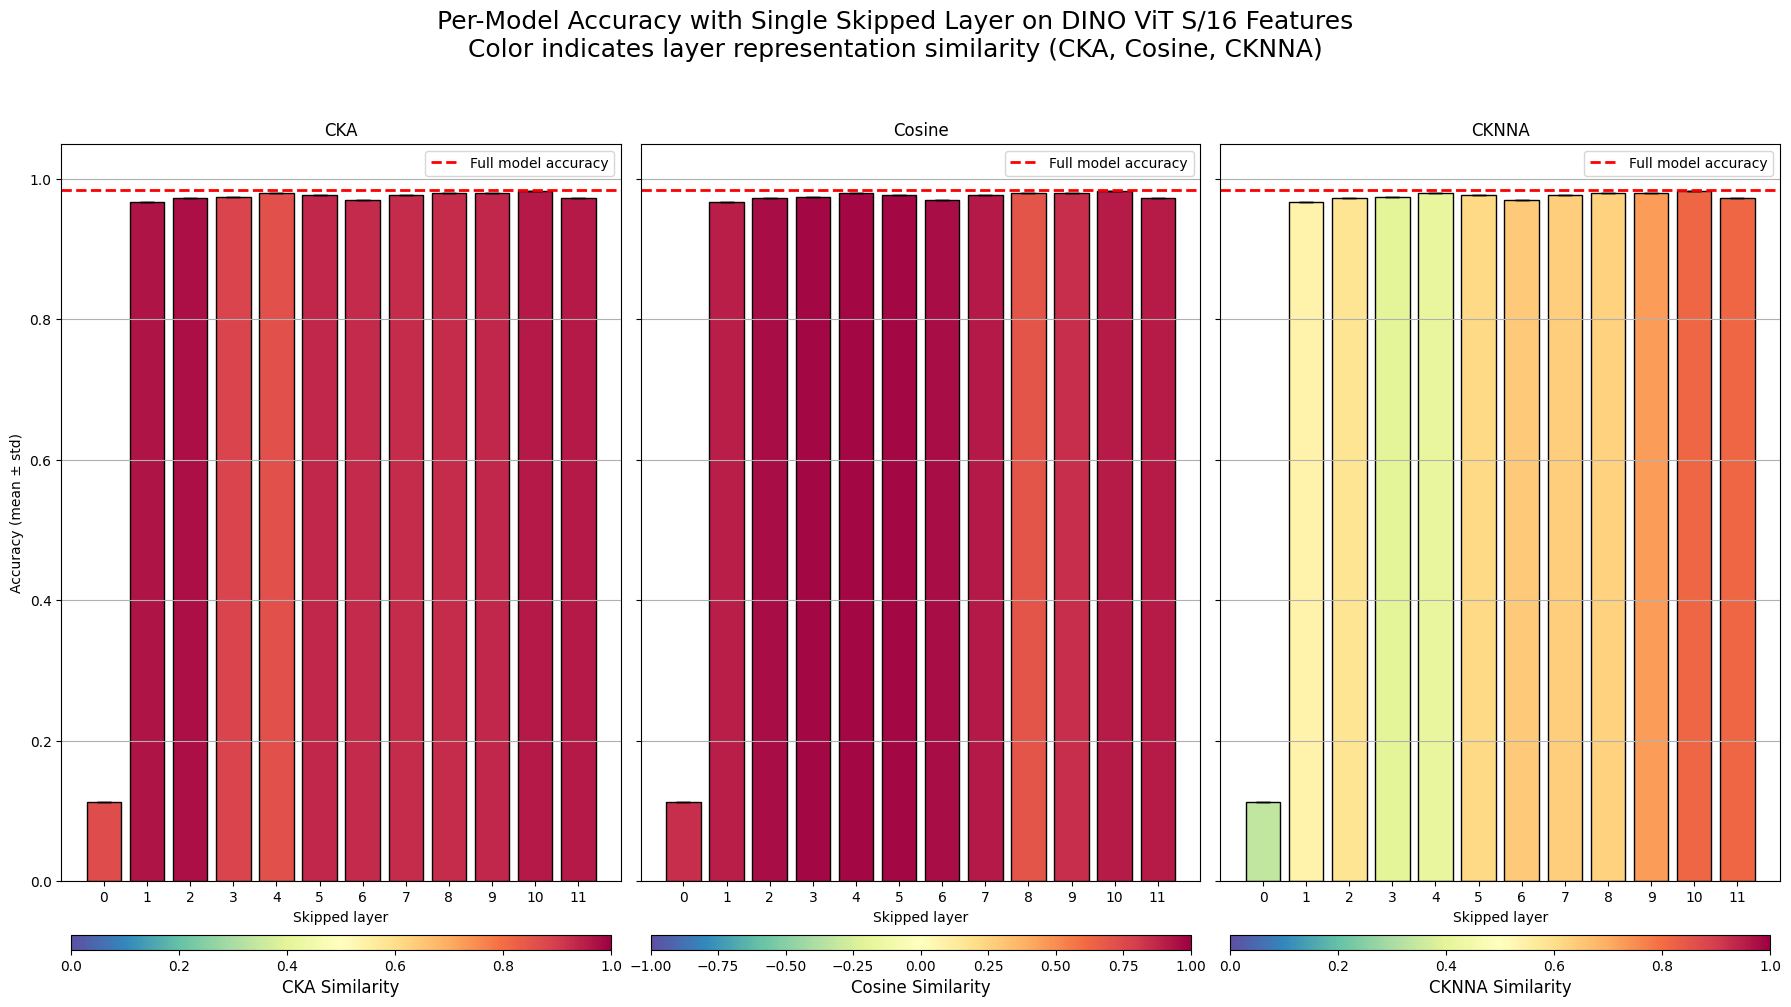

In [18]:
plot_single_skip_layer_accuracy_three_matrices_summary(
    results_single_s16,
    cka_matrix_s16,
    cos_matrix_s16,
    cknna_matrix_s16,
    results_full_s16,
    model="S/16"
)

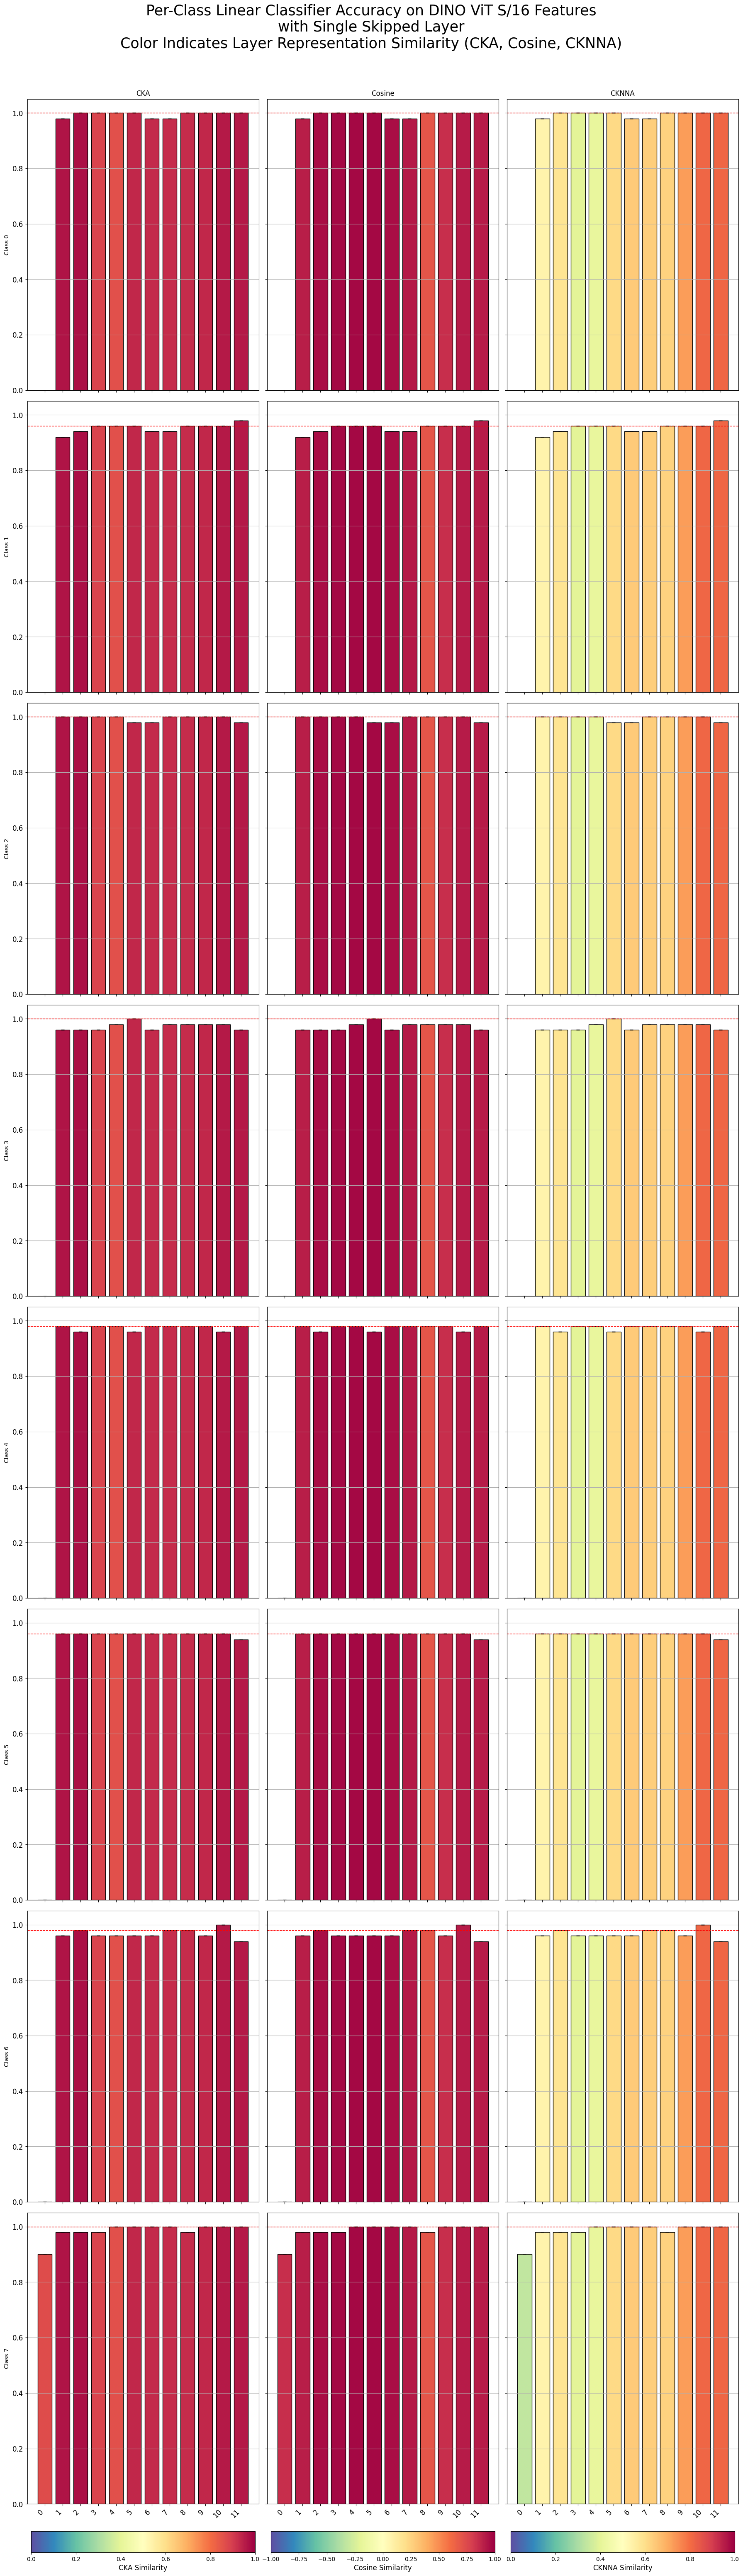

In [19]:
plot_single_skip_layer_accuracy_per_class_three_matrices(
    results_single_s16,
    cka_matrix_s16,
    cos_matrix_s16,
    cknna_matrix_s16,
    results_full_s16,
    model="S/16")

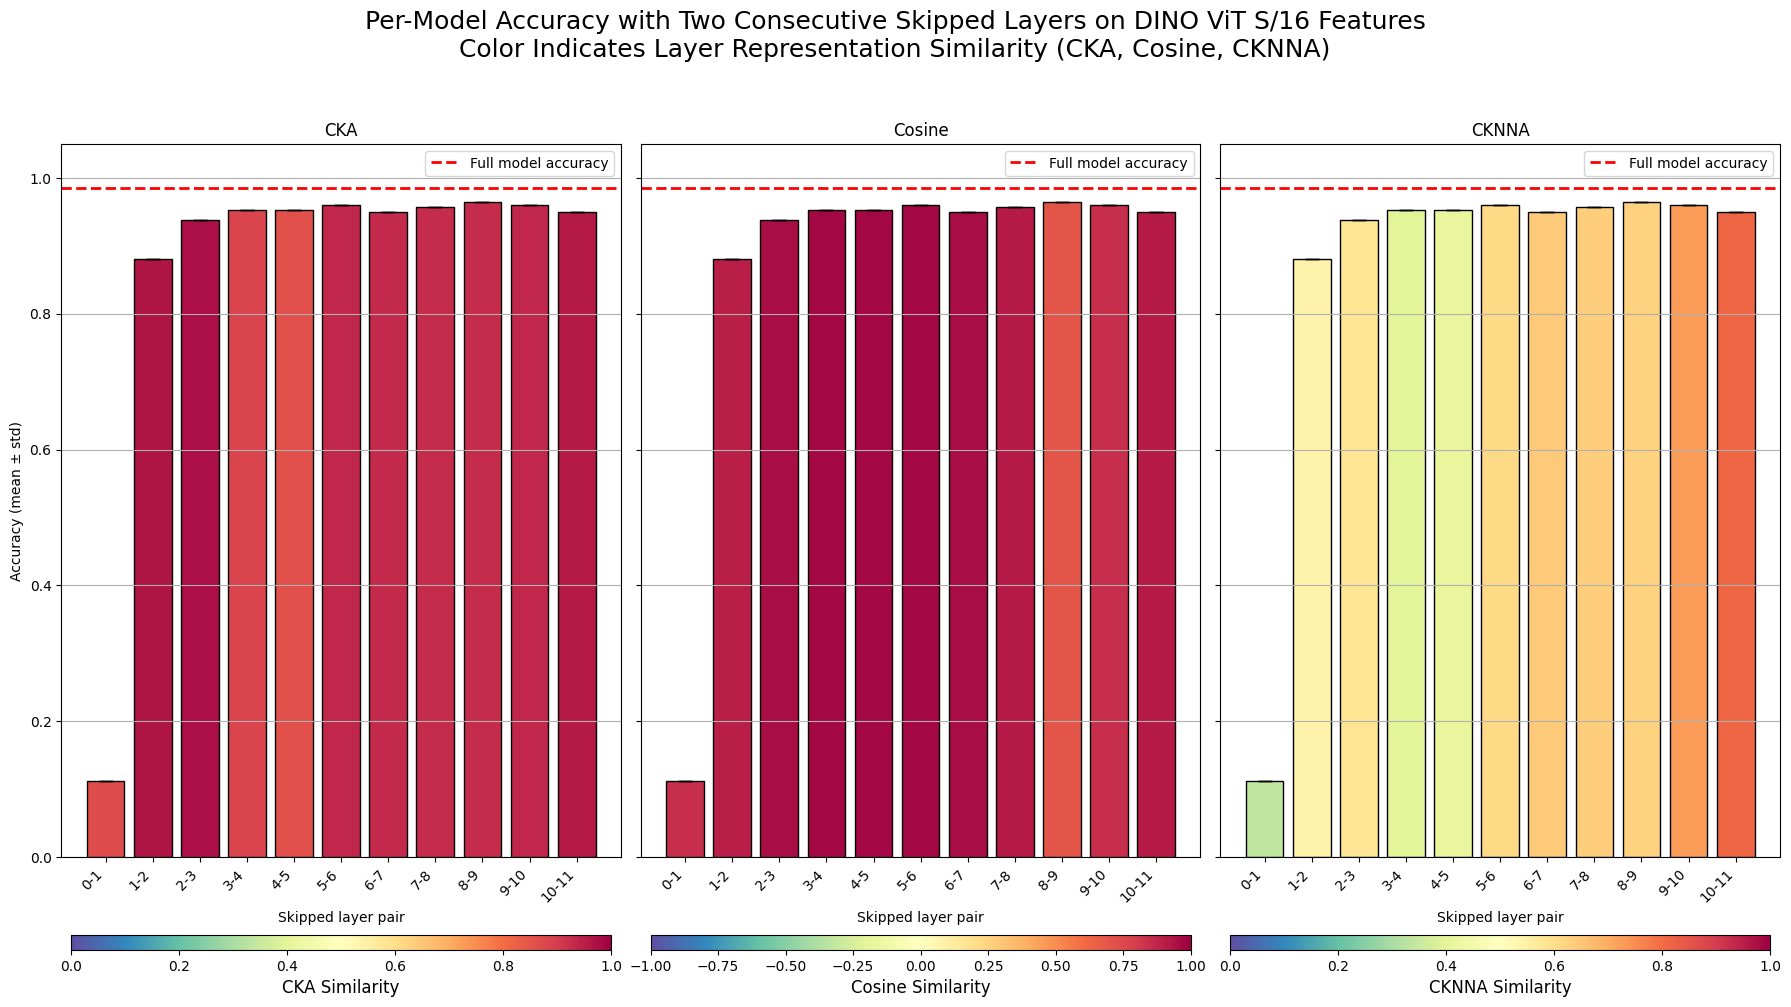

In [20]:
plot_double_skip_layer_accuracy_three_matrices_summary(
    results_double_s16,
    cka_matrix_s16,
    cos_matrix_s16,
    cknna_matrix_s16,
    results_full_s16,
    model="S/16"
)

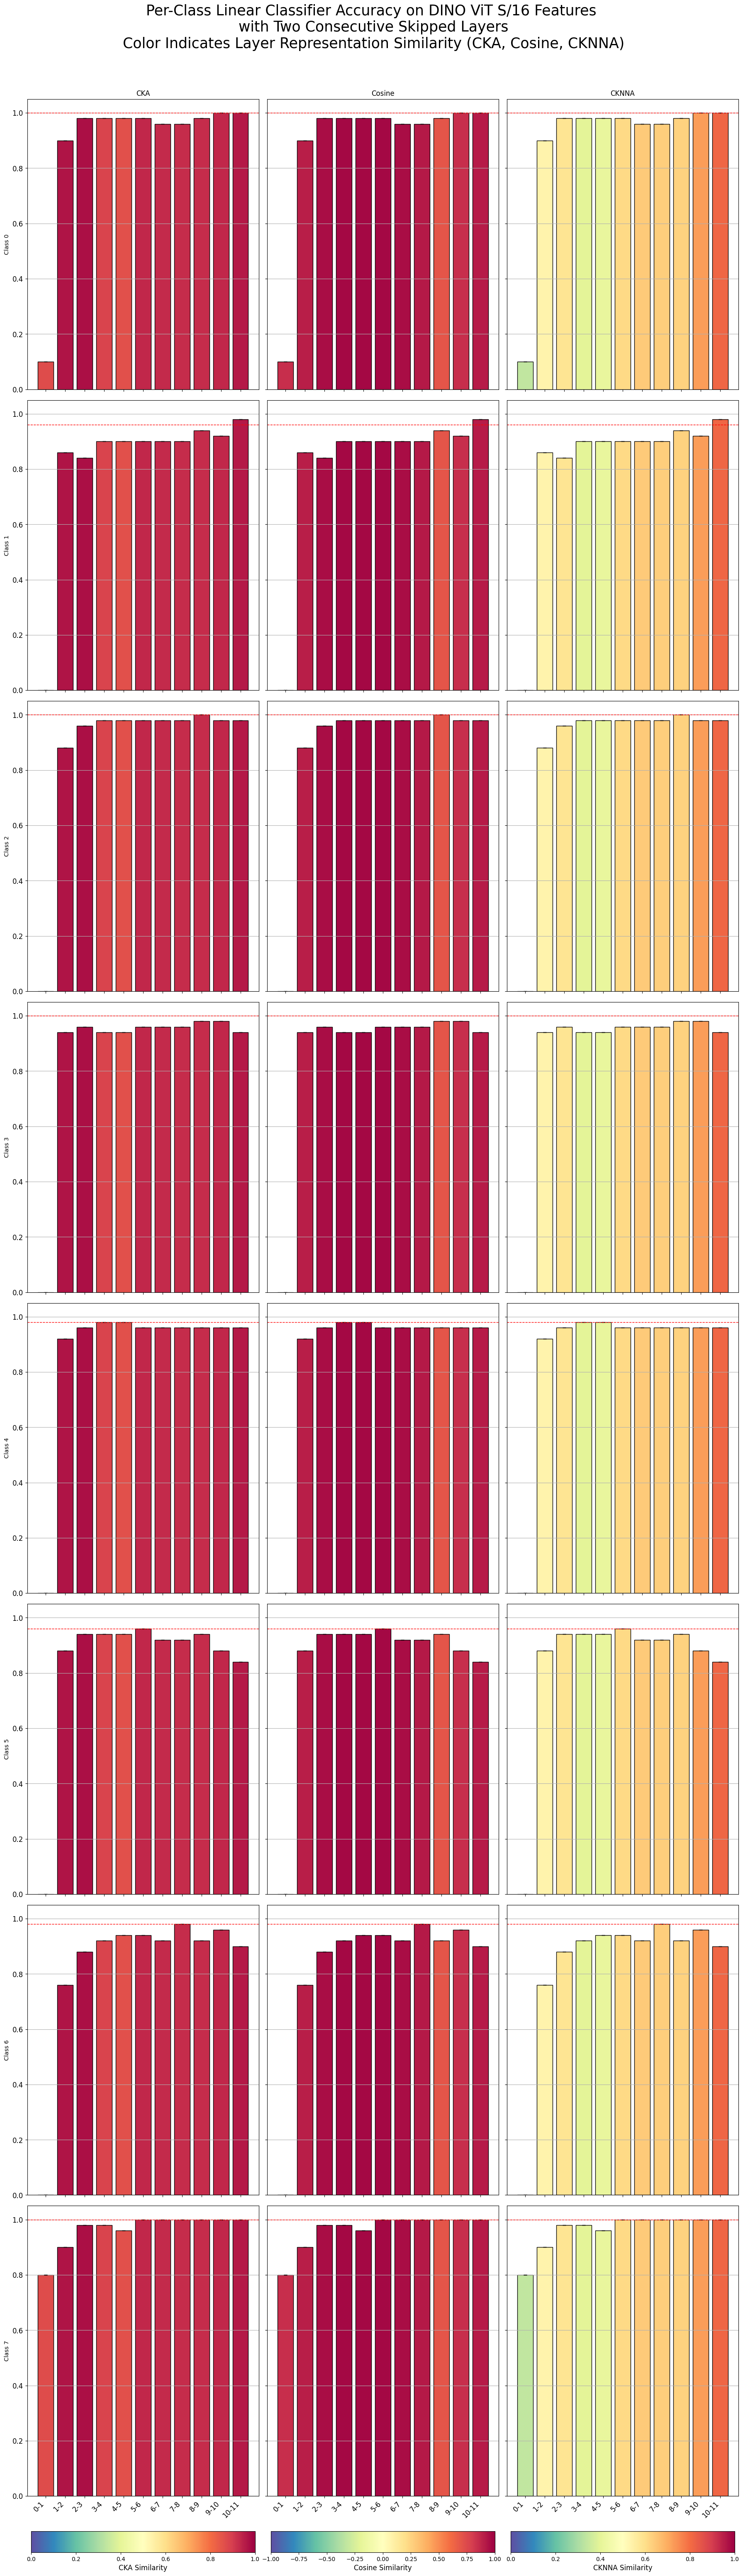

In [21]:
plot_double_skip_layer_accuracy_per_class_three_matrices(
    results_double_s16,
    cka_matrix_s16,
    cos_matrix_s16,
    cknna_matrix_s16,
    results_full_s16,
    model="S/16"
    )

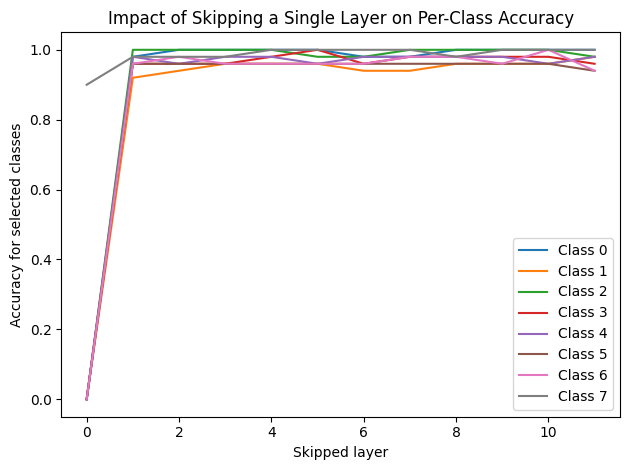

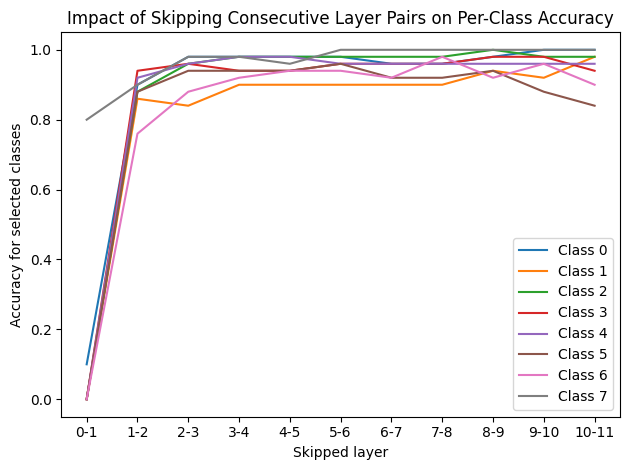

In [22]:
plot_metric_per_class_single(results_single_s16)
plot_metric_per_class_double(results_double_s16)

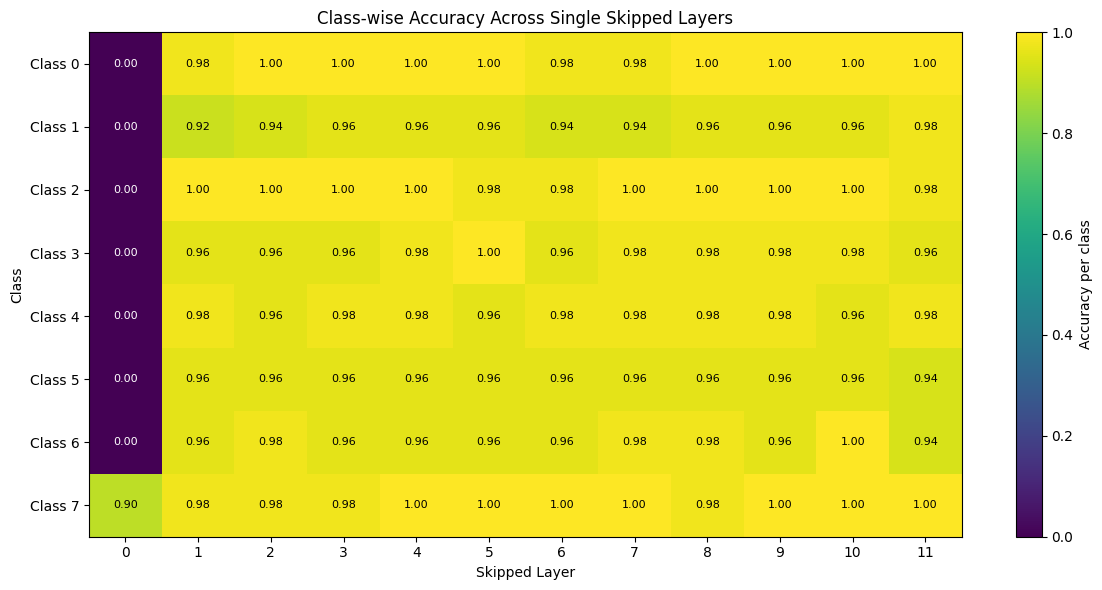

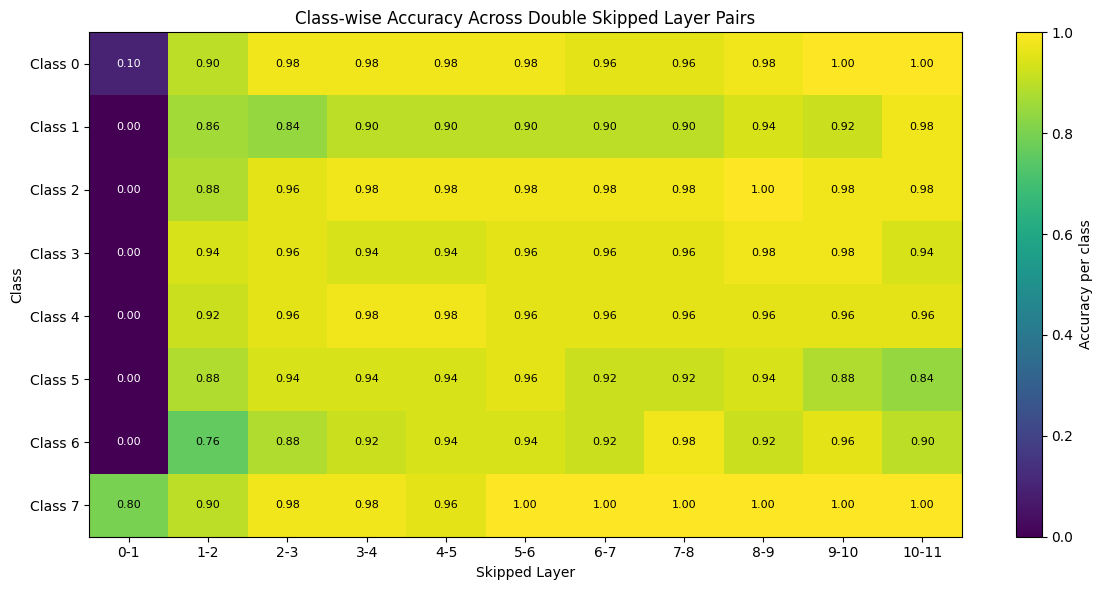

In [31]:
plot_class_heatmap_single(results_single_s16)
plot_class_heatmap_double(results_double_s16)

#### Model DINO ViT-B/8

In [32]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 768 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_B8.pth", map_location=device)
linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [ ]:
model.eval()

all_logits = collect_logits_from_batches(model, dataloader=train_loader, max_batches=20)

num_layers = len(all_logits[0])
combined_logits = []

for layer_idx in range(num_layers):
    layer_logits = [batch[layer_idx] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

cka_matrix_b8 = compute_cka_matrix(combined_logits)
cos_matrix_b8 = compute_cosine_similarity_matrix(combined_logits)
cknna_matrix_b8 = compute_cknna_matrix(combined_logits)


In [ ]:
results_full_b8 = evaluate_full_model(model, val_dataset, linear_classifier)
results_full_b8


[INFO] Evaluating full model...

[INFO] Full model, repeat 1/3


{0: np.float64(1.0), 1: np.float64(0.96), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(0.98), 5: np.float64(0.98), 6: np.float64(0.98), 7: np.float64(1.0)}
[INFO] Full model, repeat 2/3


{0: np.float64(1.0), 1: np.float64(0.96), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(0.98), 5: np.float64(0.98), 6: np.float64(0.98), 7: np.float64(1.0)}
[INFO] Full model, repeat 3/3


{0: np.float64(1.0), 1: np.float64(0.96), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(0.98), 5: np.float64(0.98), 6: np.float64(0.98), 7: np.float64(1.0)}


[{'skipped_layers': [],
  'accuracy_mean': np.float64(0.9875000000000002),
  'accuracy_std': np.float64(1.1102230246251565e-16),
  'precision_mean': np.float64(0.9875960384153663),
  'precision_std': np.float64(1.1102230246251565e-16),
  'recall_mean': np.float64(0.9875000000000002),
  'recall_std': np.float64(1.1102230246251565e-16),
  'f1_mean': np.float64(0.9874739973997398),
  'f1_std': np.float64(1.1102230246251565e-16),
  'accuracy_per_class_mean': {0: np.float64(1.0),
   1: np.float64(0.96),
   2: np.float64(1.0),
   3: np.float64(1.0),
   4: np.float64(0.98),
   5: np.float64(0.98),
   6: np.float64(0.98),
   7: np.float64(1.0)},
  'accuracy_per_class_std': {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0)},
  'precision_per_class_mean': {np.int64(0): np.float64(0.9803921568627451),
   np.int64(1): np.float64(0.9795918367346937),
   np.int64(2): np.

In [ ]:
results_single_b8 = evaluate_skipped_layers(model, val_dataset, linear_classifier)
results_single_b8


[INFO] Evaluating individual skipped layers...

[INFO] Skipping layer [0], repeat 1/3


[INFO] Skipping layer [0], repeat 2/3


[INFO] Skipping layer [0], repeat 3/3


[INFO] Skipping layer [1], repeat 1/3


[INFO] Skipping layer [1], repeat 2/3


...

[INFO] Skipping layer [10], repeat 3/3


[INFO] Skipping layer [11], repeat 1/3


[INFO] Skipping layer [11], repeat 2/3


[INFO] Skipping layer [11], repeat 3/3


[{'skipped_layers': [0],
  'accuracy_mean': np.float64(0.1075),
  'accuracy_std': np.float64(0.0),
  'precision_mean': np.float64(0.11048656000861883),
  'precision_std': np.float64(0.0),
  'recall_mean': np.float64(0.1075),
  'recall_std': np.float64(1.3877787807814457e-17),
  'f1_mean': np.float64(0.09056863019113966),
  'f1_std': np.float64(1.3877787807814457e-17),
  'accuracy_per_class_mean': {0: np.float64(0.08),
   1: np.float64(0.08),
   2: np.float64(0.3),
   3: np.float64(0.20000000000000004),
   4: np.float64(0.08),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.12)},
  'accuracy_per_class_std': {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(2.7755575615628914e-17),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0)},
  'precision_per_class_mean': {np.int64(0): np.float64(0.1176470588235294),
   np.int64(1): np.float64(0.26666666666666666),
   np.int64(2): np.float64(0.125),
   np.i

In [ ]:
results_double_b8 = evaluate_skipped_layer_pairs(model, val_loader, linear_classifier)
results_double_b8


[INFO] Evaluating pairs of skipped layers...

[INFO] Skipping layers [0, 1], repeat 1/3


[INFO] Skipping layers [0, 1], repeat 2/3


[INFO] Skipping layers [0, 1], repeat 3/3


[INFO] Skipping layers [1, 2], repeat 1/3


[INFO] Skipping layers [1, 2], repeat 2/3


...

[INFO] Skipping layers [9, 10], repeat 3/3


[INFO] Skipping layers [10, 11], repeat 1/3


[INFO] Skipping layers [10, 11], repeat 2/3


[INFO] Skipping layers [10, 11], repeat 3/3


[{'skipped_layers': [0, 1],
  'accuracy_mean': np.float64(0.145),
  'accuracy_std': np.float64(0.0),
  'precision_mean': np.float64(0.07159272605163963),
  'precision_std': np.float64(0.0),
  'recall_mean': np.float64(0.14500000000000002),
  'recall_std': np.float64(0.0),
  'f1_mean': np.float64(0.0902160818720071),
  'f1_std': np.float64(0.0),
  'accuracy_per_class_mean': {0: np.float64(0.0),
   1: np.float64(0.10000000000000002),
   2: np.float64(0.0),
   3: np.float64(0.56),
   4: np.float64(0.44),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.06)},
  'accuracy_per_class_std': {0: np.float64(0.0),
   1: np.float64(1.3877787807814457e-17),
   2: np.float64(0.0),
   3: np.float64(0.0),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0)},
  'precision_per_class_mean': {np.int64(0): np.float64(0.0),
   np.int64(1): np.float64(0.10638297872340426),
   np.int64(2): np.float64(0.0),
   np.int64(3): np.float64(0.2616822429906542),
 

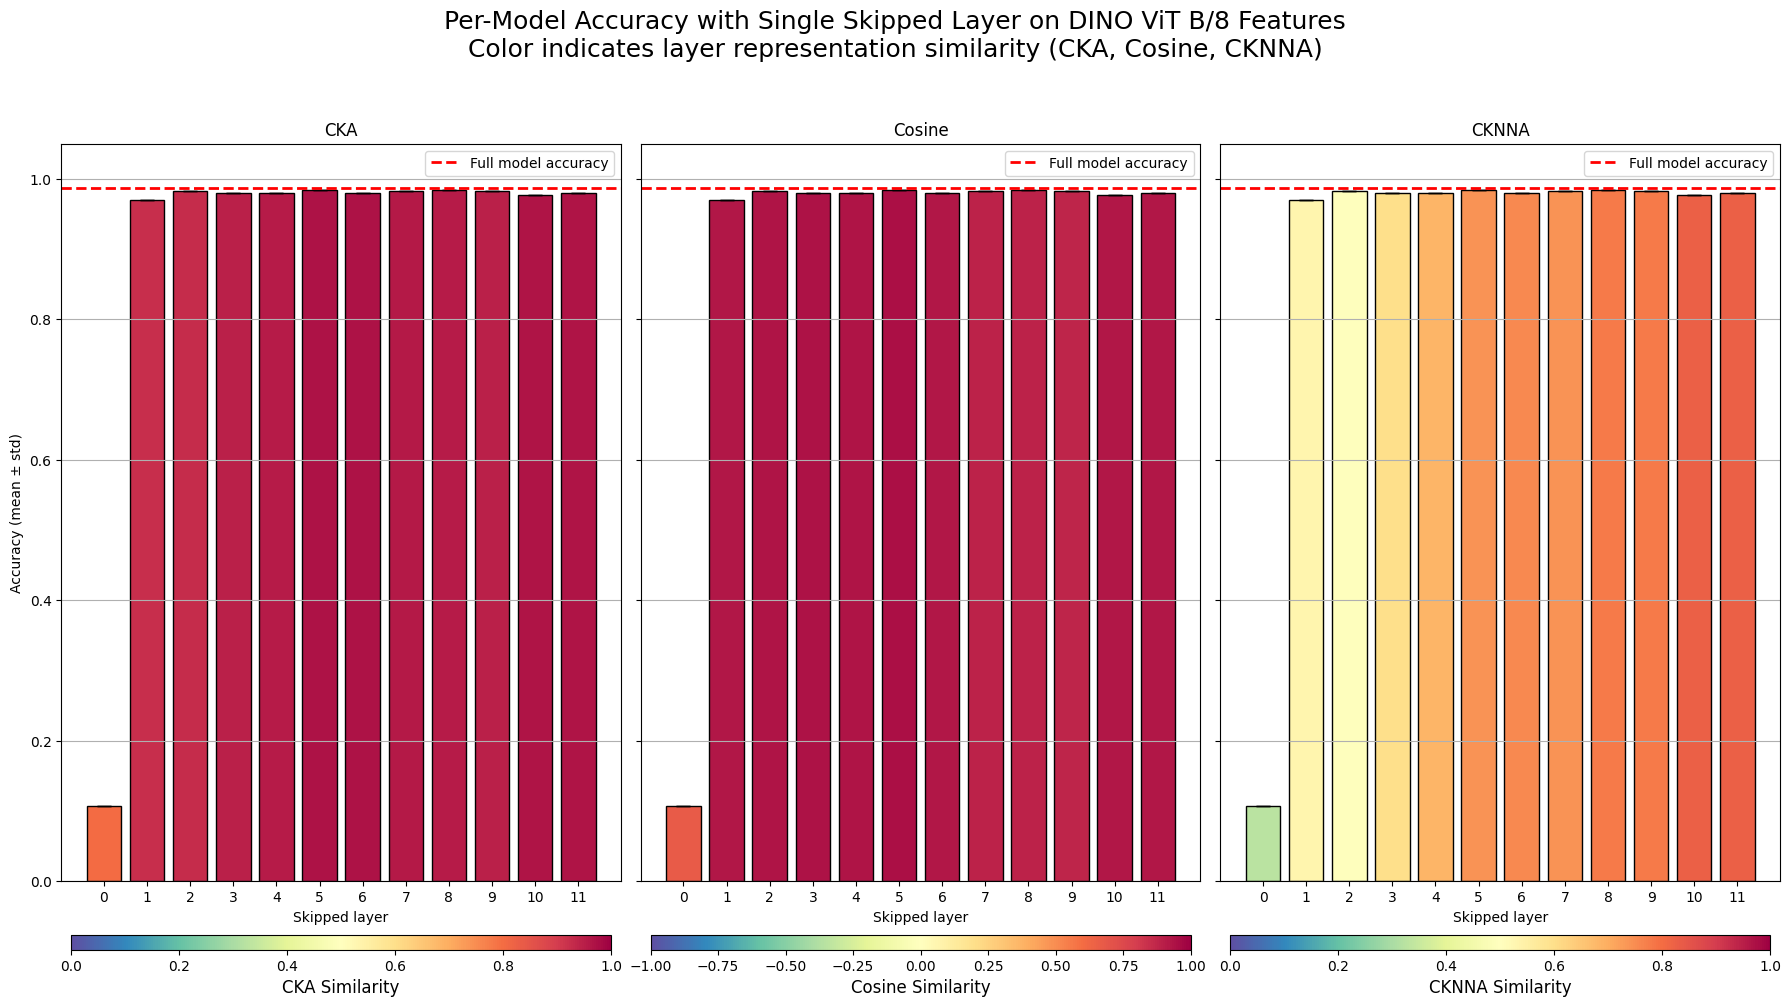

In [35]:
plot_single_skip_layer_accuracy_three_matrices_summary(
    results_single_b8,
    cka_matrix_b8,
    cos_matrix_b8,
    cknna_matrix_b8,
    results_full_b8,
    model="B/8"
)

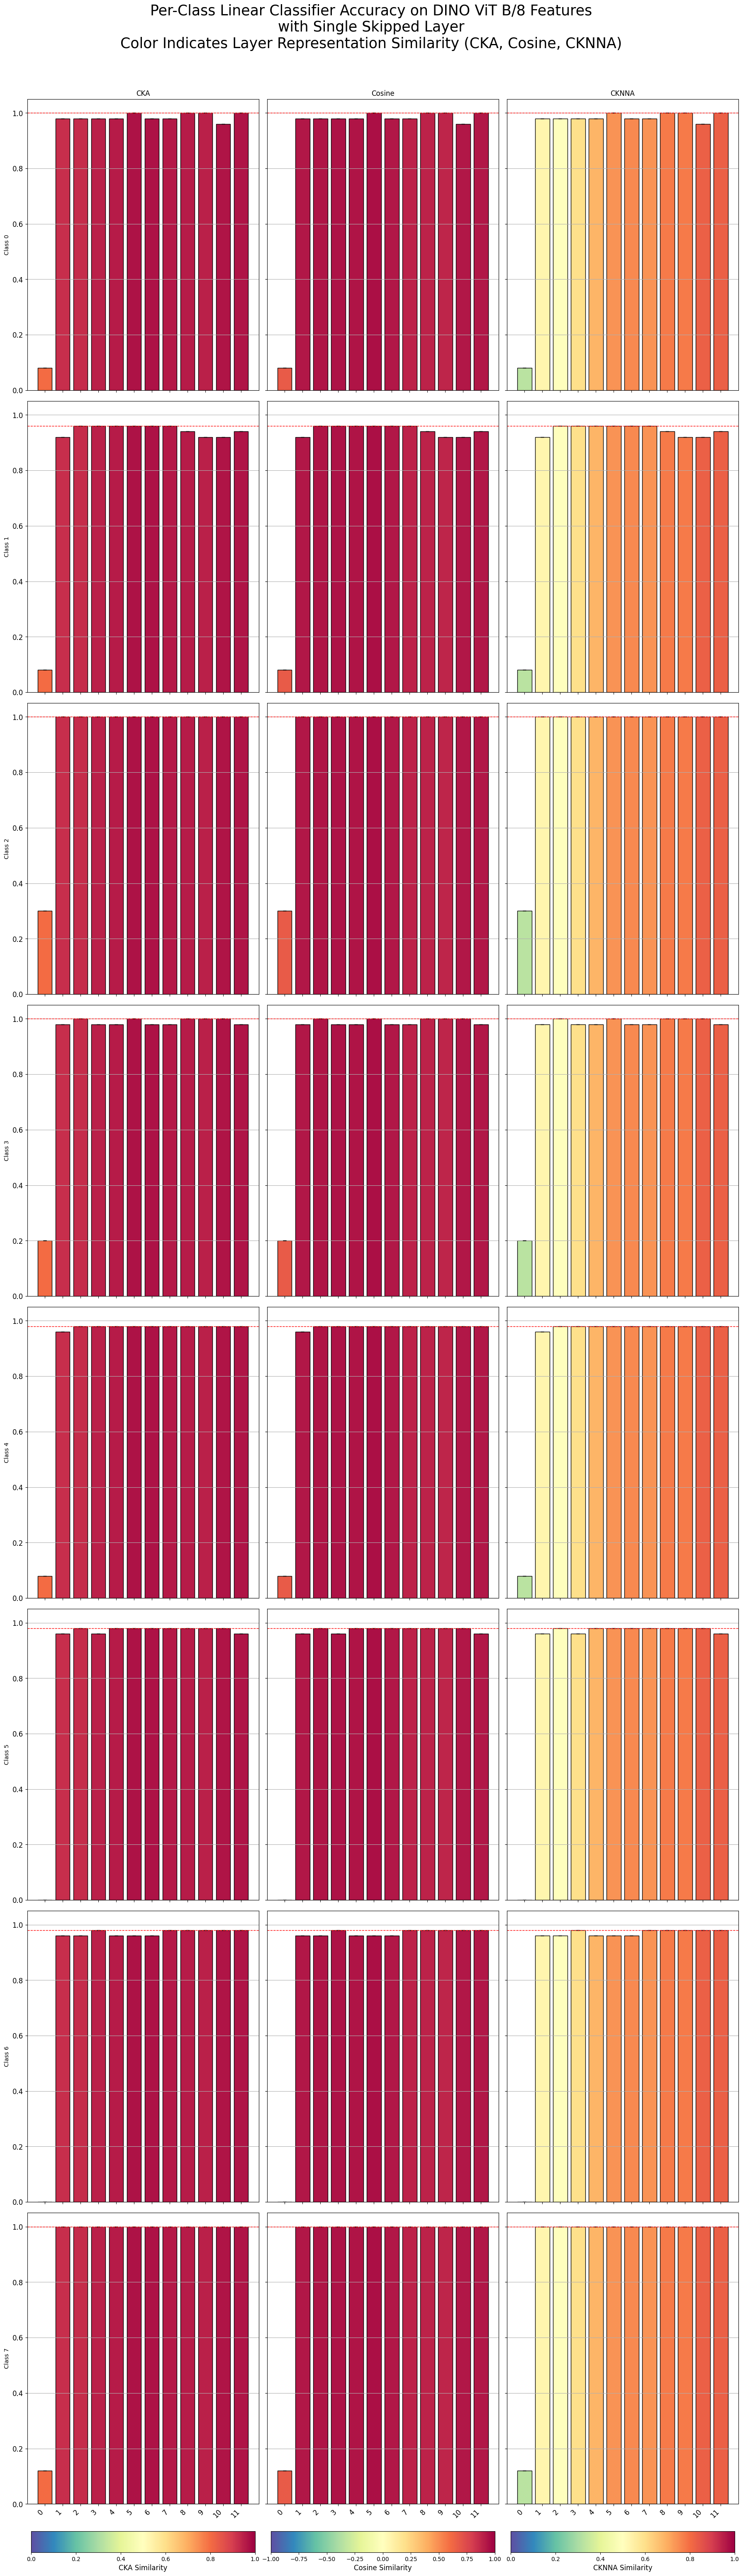

In [36]:
plot_single_skip_layer_accuracy_per_class_three_matrices(
    results_single_b8,
    cka_matrix_b8,
    cos_matrix_b8,
    cknna_matrix_b8,
    results_full_b8,
    model="B/8"
)

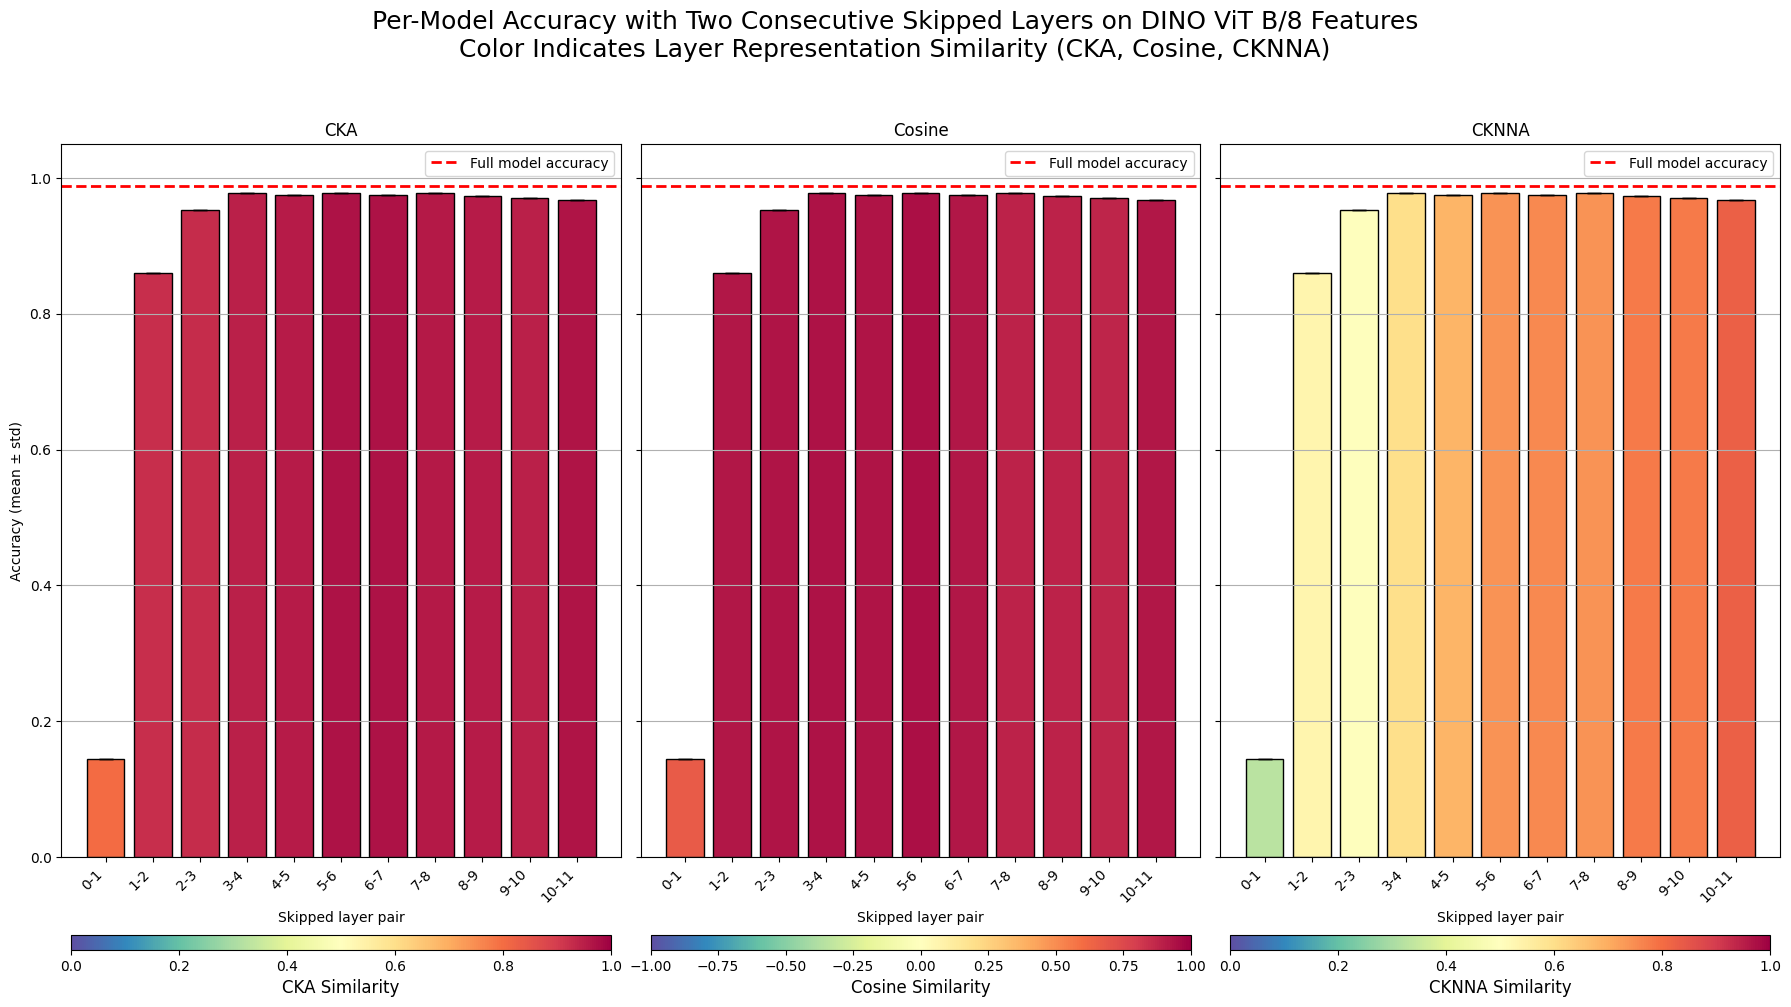

In [39]:
plot_double_skip_layer_accuracy_three_matrices_summary(
    results_double_b8,
    cka_matrix_b8,
    cos_matrix_b8,
    cknna_matrix_b8,
    results_full_b8,
    model="B/8"
)

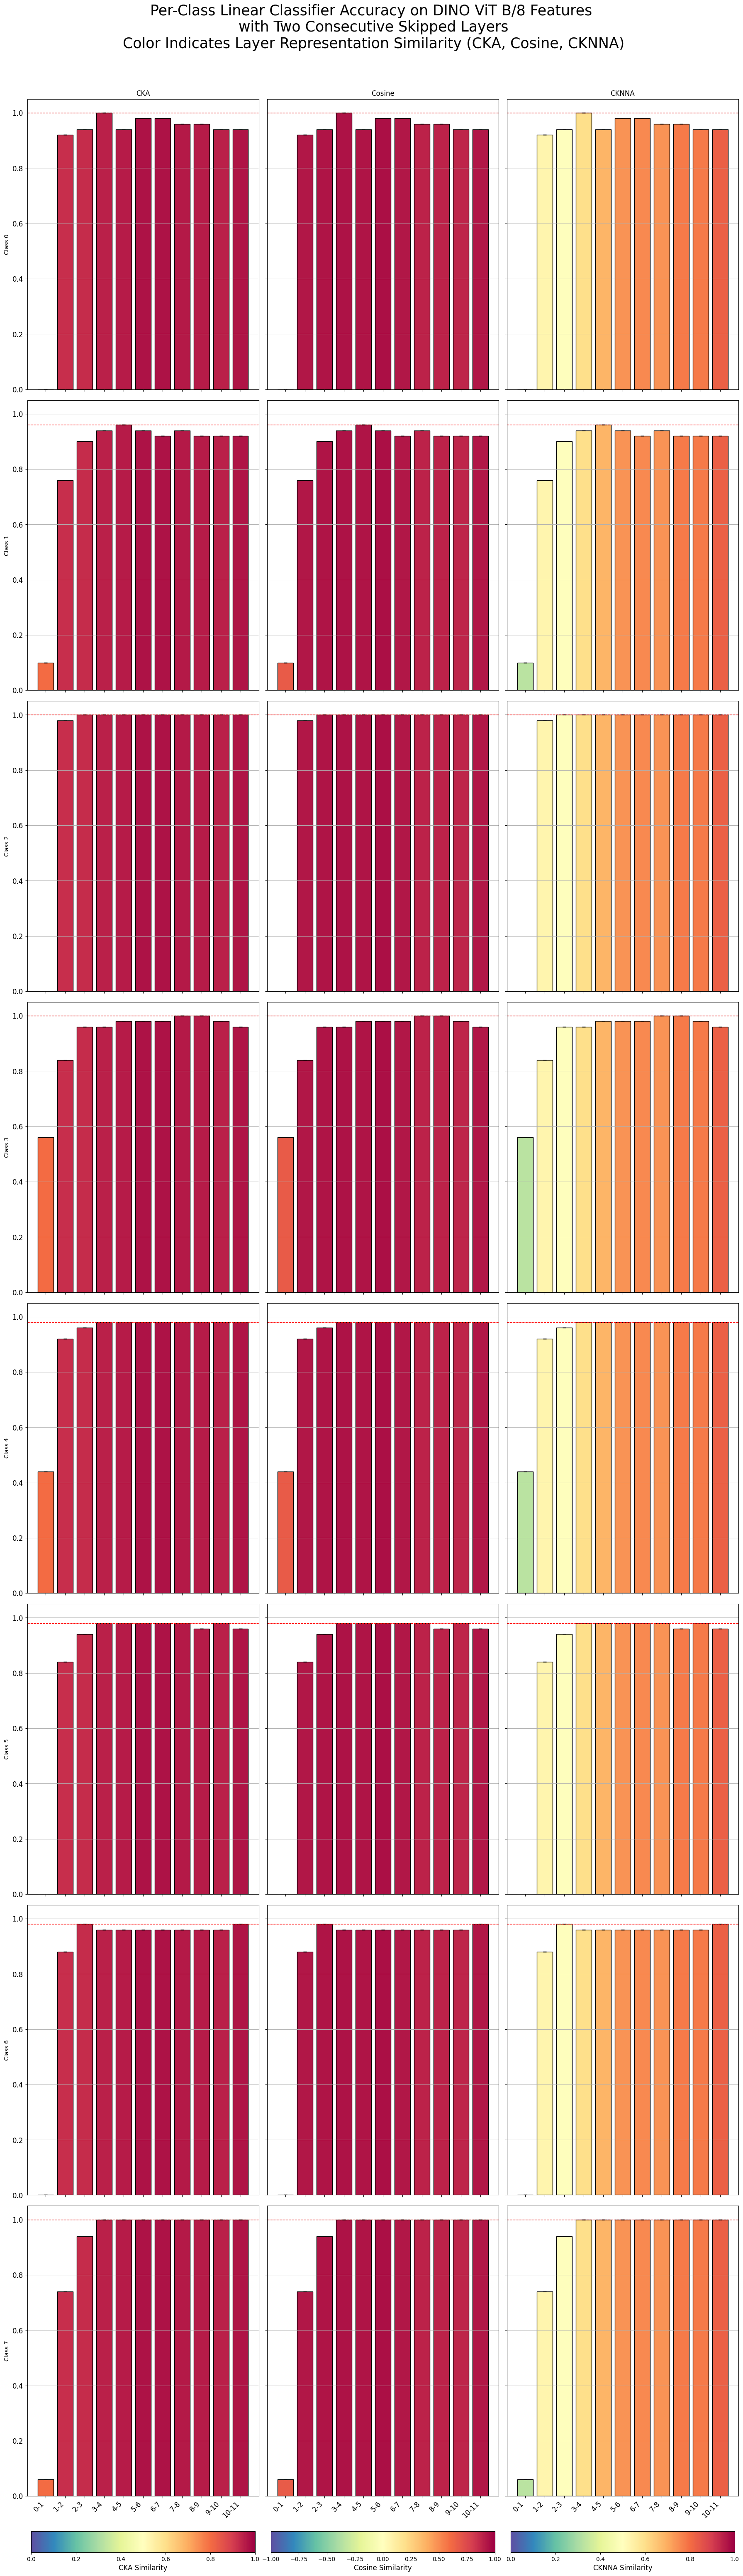

In [40]:
plot_double_skip_layer_accuracy_per_class_three_matrices(
    results_double_b8,
    cka_matrix_b8,
    cos_matrix_b8,
    cknna_matrix_b8,
    results_full_b8,
    model="B/8"
    )

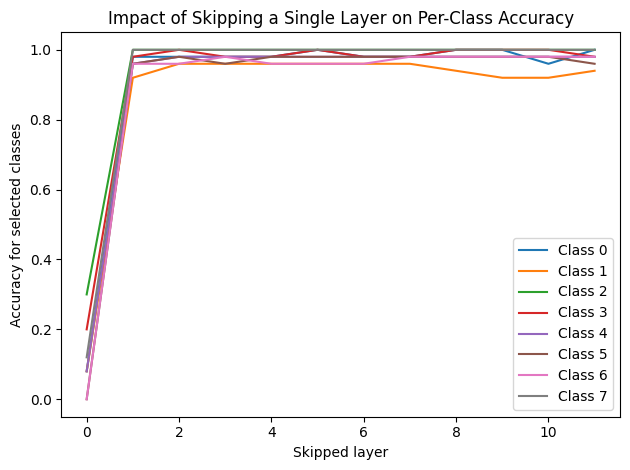

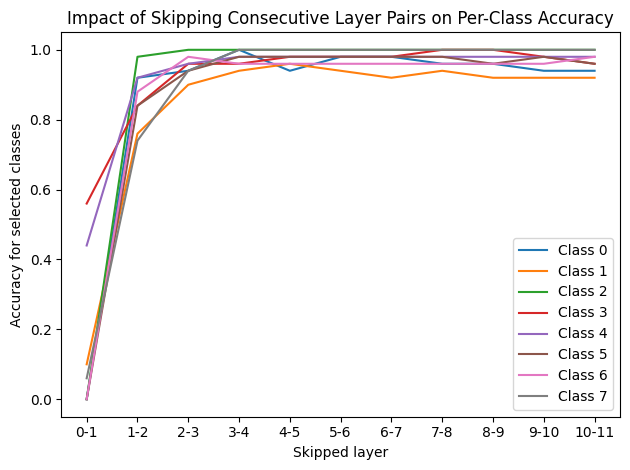

In [41]:
plot_metric_per_class_single(results_single_b8)
plot_metric_per_class_double(results_double_b8)

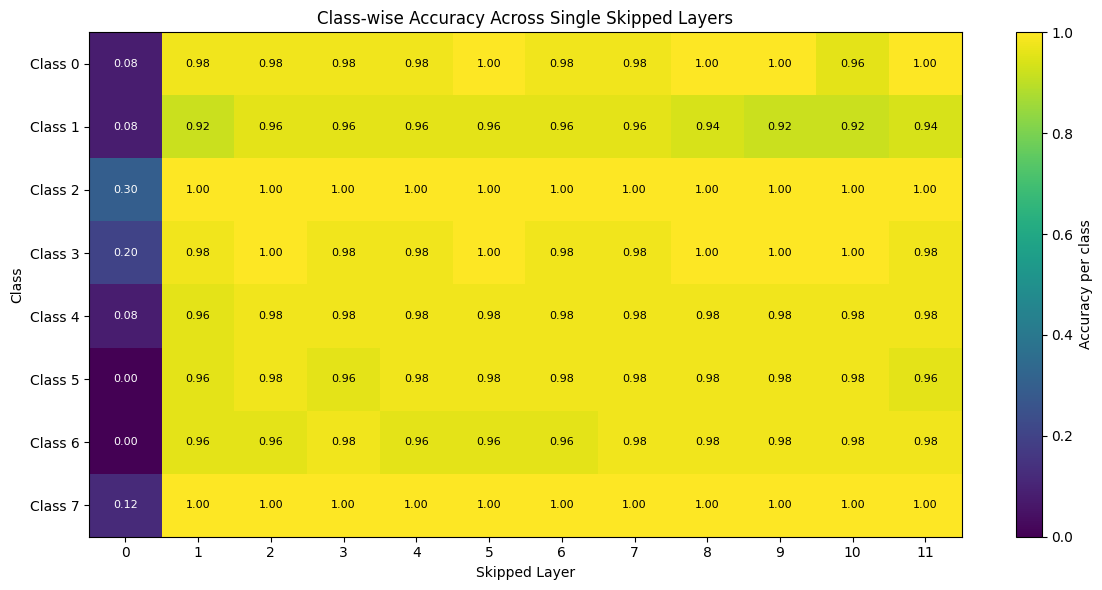

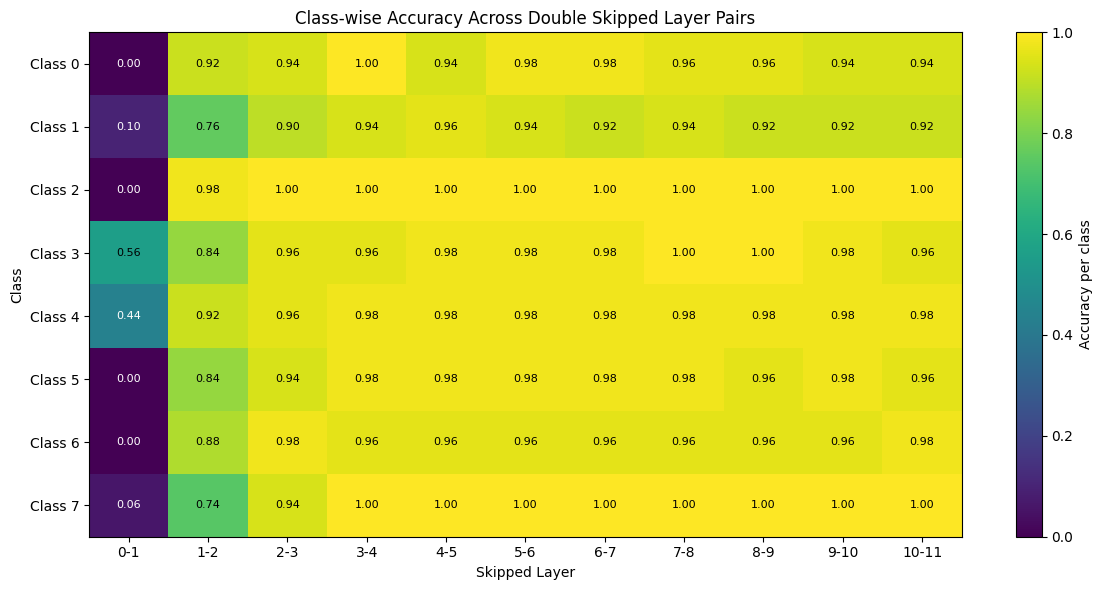

In [42]:
plot_class_heatmap_single(results_single_b8)
plot_class_heatmap_double(results_double_b8)

### Analysis of Layer Skipping Effects in DINO ViT-S/16 and ViT-B/8 Representations

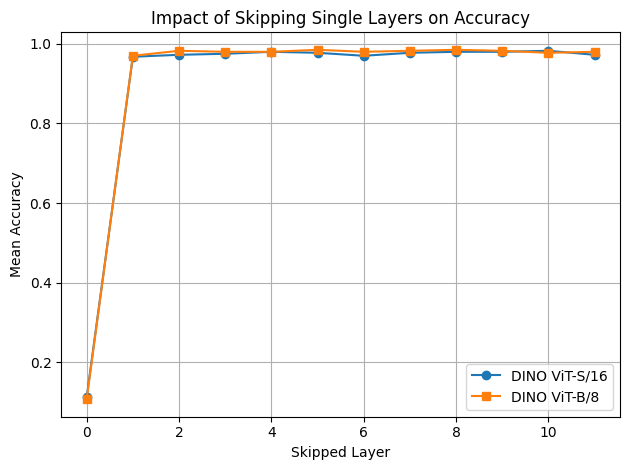

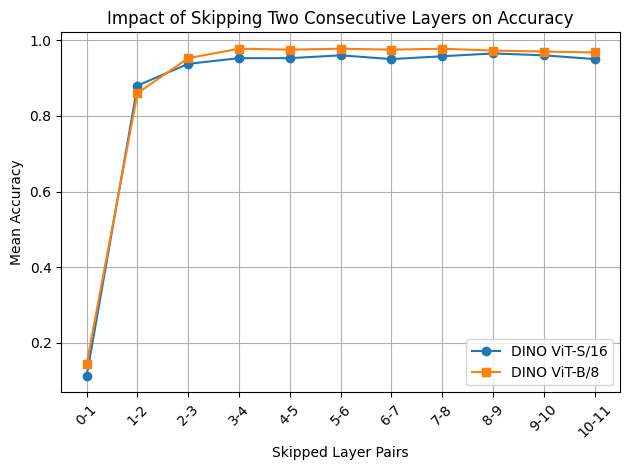

In [55]:
compare_single_skip_accuracy(results_single_s16, results_single_b8)

compare_double_skip_accuracy(results_double_s16, results_double_b8)
